# SHAP + Network Analysis

## Purpose: 
{TODO}


## Packages, Options and Class Instantiation

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 

_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

%load_ext autoreload 
%autoreload 2

    
import importlib

SHAP_analysis_class = getattr(
    importlib.import_module("1_shap_network_analyzer"), 
    "ShapNetworkInvestigator"
)


data_modes = ["All-Data", "Unique-Binding"]
binding_modes = ["Bound-Only", "NOT-Bound-Only"]
FDR_cutoffs = [0.1, 0.05]

investigator = SHAP_analysis_class()
investigator.hash_metadata

2025-10-08 15:14:07.341 | SUCCESS  | 1_shap_network_analyzer:make_model_metadata_from_hash:322 - FROM CACHE: loaded hash metadata file


,hash,name,gamma,n_jobs,max_depth,objective,reg_alpha,subsample,reg_lambda,eval_metric,n_estimators,learning_rate,colsample_bytree,min_child_weight,early_stopping_rounds,cell_line,seed,shap_expected_value,alpha,l1_ratio
0,e048c0490ea6f3cfa263c0d3e66e9795583c45a8a5ef2d2715dc08920c13290d,ElasticNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HepG2,17,NaN,0.000100,1.0
1,d3b95df0842783c0abe226462e97e83be58aa11ed676401dfd640438c3ce1e94,ElasticNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K562,17,NaN,0.000838,0.1
2,c859f2093367b69aff13a5770150b486a226578fc6f13f1aaacda1b4b145d0c6,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,0.1,1.0,"['rmse', 'logloss']",100000.0,0.05,1.00,30.0,100.0,HepG2,17,0.843707,NaN,NaN
3,3cfd52c46852f8a3afe7b35fc548682916e347a79f66b05f13dec661b727a46b,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.5,1.0,0.1,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,0.848065,NaN,NaN
4,e94727bc02235363dfbeed3e0818618e62955e5449e3a143e3c560f5e58d0e3c,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,1.0,1.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,0.845504,NaN,NaN
5,f784792c7eeb91135eb22d916c79bfbef091e56d2a0a8f4ac8afa92d1e9e1538,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.5,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,0.846334,NaN,NaN
6,fdf52464ba1145bed424d92827c559d851550a0117d96a630474c08e558ac4fd,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,1.0,5.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,0.846222,NaN,NaN
7,8f310837d07486fd286d4ad7975dcdd0c2bdfc795d2d59b1bb38f3ecc50044ca,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.5,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,0.868015,NaN,NaN
8,1a5a622d0e4fb1bc7aeedf84cc41f73cd02c52b204046c305a4746fe7101c069,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.0,1.0,0.1,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,0.864827,NaN,NaN
9,f93fa76e4f7b67d2494c9ef5eadbafe3f38bb4f2cad488040116e580f0cc0de2,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.8,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,0.866905,NaN,NaN


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Data QC</h1>

## Check for Nulls in `SHAP`/Binding

In [ ]:
investigator.run_data_quality_assertions()

## Assert `SHAP` additivity


In [ ]:
investigator.assert_SHAP_additivity()

## Check no `Local SHAP` variance per binding pattern

In [ ]:
table = investigator.check_no_SHAP_variance_per_binding_pattern()

table.sample(10)
table["num_unique_shap_rows"].value_counts()

## Create Final SHAP Cache

In [ ]:
investigator.load_final_SHAP_data(underlying_data="All-Data")

In [ ]:
for key in investigator.final_all_data_SHAP_data: 
    investigator.final_all_data_SHAP_data[key].shape
    investigator.final_all_data_SHAP_data[key].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Predicted vs Actual Plots</h1>

In [ ]:
for mode in data_modes:

    investigator.plot_actual_vs_predicted_for_best_models(underlying_data = mode)

In [ ]:
investigator.plot_actual_vs_predicted_for_best_models(underlying_data = "Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">View Feature Distribution of Local SHAP</h1>

In [ ]:
# investigator.plot_local_SHAP_distribution_per_feature_as_mp4()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP Across Models and for Average Local SHAP</h1>

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

for key in tables: 
    key
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.plot_global_SHAP_mean_vs_variance(mode="5_dfs", binding_unique="Unique-Binding")

for key in tables: 
    key 
    tables[key].head()


In [ ]:
investigator.plot_global_SHAP_coefficient_of_variation(mode='5_dfs', binding_unique="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Variance Analysis</h1>

In [ ]:
investigator.plot_SHAP_CV()

In [ ]:
investigator.plot_SHAP_std()

In [ ]:
investigator.plot_local_SHAP_mean_vs_variance()

In [ ]:
for mode in binding_modes: 
    mode
    investigator.calculate_local_SHAP_mean_vs_variance_deciles(mode=mode)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">ElasticNet</h1>


In [ ]:
elasticnet = investigator.load_elasticnet_coefficients()

for key in elasticnet: 
    key 
    elasticnet[key]["coefficients"].head()

In [ ]:
investigator.plot_elasticnet_coefficients()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Position 3 + 4 Significance in Global SHAP/ElasticNet</h1>


In [ ]:
investigator.check_position_3_and_4_significance_for_global_SHAP_and_elasticnet()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Is Position 3/4 Activator-Like and Other Positions Repressor-Like?

In [ ]:
investigator.is_position_3_4_activating_and_others_repressing()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Make Global SHAP Plots with Variations</h1>

# Variations: 
* Unique Binding Patterns 
* Feature is bound
* Feature is NOT bound
* Feature is NOT bound in CONTROL
* Feature is NOT bound in ROW W/ RBP KD AT ANY POSITION
* Feature is NOT bound in ROW W/ RBP KD AT SPECIFIC POSITION
* Use signed (not absolute value) summation of Local SHAP
* `Log-Odds` signed summation of Bound Only Local SHAP

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_between_unique_binding_and_all_data()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_specialized_vs_regular_global_SHAP(underlying_data="Unique-Binding")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="CTRL")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-CTRL", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD_at_position")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD_at_position", binding_unique="All-Data")

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    tables = investigator.calculate_specialized_global_SHAP(mode=mode, condition=None, underlying_data="Unique-Binding")
    for key in tables: 
        tables[key]

In [ ]:
for mode in binding_modes: 
    
    mode = "Signed-Local-SHAP-Mean-" + mode
    
    investigator.plot_global_SHAP(mode=mode, binding_unique="Unique-Binding")

In [ ]:
investigator.compare_bound_global_SHAP_and_signed_mean_bound_local_SHAP()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", condition=None, underlying_data="Unique-Binding")

for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Signed-Local-SHAP-Mean-LOG_ODDS-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.compare_signed_mean_bound_local_SHAP_between_probability_and_log_odds_units()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP across Binding Modes & Positional Vignettes


In [ ]:
investigator.plot_global_SHAP_distributions_across_binding_modes()

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode = "Bound-Only", underlying_data="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode="Signed-Local-SHAP-Mean-Bound-Only", underlying_data="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Sign Analysis</h1>

# Includes: 


* Percentage of local SHAP that is non-zero at different cutoffs
* Percentage of local SHAP positive/negative either when feature is bound or unbound
* Understanding activation and repression through custom metric

## % Non-Zero SHAP

In [ ]:
investigator.calculate_local_SHAP_percent_non_zero(mode="Unique-Binding").head()

In [ ]:
investigator.plot_local_SHAP_percent_non_zero()

## Negative & Positive Local SHAP

In [ ]:
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "NOT-Bound-Only", underlying_data="Unique-Binding")
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "Bound-Only", underlying_data="Unique-Binding")


In [ ]:
investigator.plot_percent_positive_and_negative_local_SHAP_per_feature(underlying_data="Unique-Binding")

## Custom Metric for Activation and Repression Behavioral Understanding

In [ ]:
for binding_mode in ["Bound-Only", "NOT-Bound-Only"]: 
    investigator.calculate_activator_repressor_behavior_score(binding_mode=binding_mode, underlying_data="Unique-Binding").head()

In [ ]:
investigator.plot_activator_repressor_behavior_score(underlying_data = "Unique-Binding")

In [ ]:
investigator.plot_activator_repressor_behavior_score_vs_percent_positive_and_negative(underlying_data="Unique-Binding")

<h1 style="color: red; font-weight: bold; font-size: 60px;">INCOMPLETE</h1>

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP for Zero Binding Rows</h1>

Looks at: 

* Heatmap of `NOT Bound` "`Global SHAP`" for rows of: 
    * Control
    * The KD of the RBP for that feature
    * That feature having in-silico knockdown 

<br>


* Heatmap of % of zero binding events that have "0" `Local SHAP`

<br>

In [ ]:
investigator.shap_for_zero_binding_features_by_condition()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential Splicing Events</h1>

### Focuses on: 

* RBP-specific: 
    * \# Significant Diff Events 
    * \# Significant Diff Events w/ RBP KD at **ANY** Position
* Feature-specific: 
    * \# Significant Diff Events w/ RBP KD at **SPECIFIC** Position

<br>

* `Fisher's Exact` test for association between binding and significant splicing


In [ ]:
investigator.create_feature_metric_summary_table()

In [ ]:
investigator.plot_differential_splicing_types()


In [ ]:
investigator.plot_differential_ranks()

In [ ]:
investigator.plot_differential_ratios()

In [ ]:
investigator.plot_matching_differential_ratios_scatterplot()

In [ ]:
for cutoff in FDR_cutoffs: 
    investigator.binding_vs_diff_events_fishers_association(FDR_threshold = cutoff)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Metric w/ Regulatory Explanation</h1>

* `Global SHAP`
* `ElasticNet coefficients`
* `Total Binding`
* `# Differential Events`

In [ ]:
investigator.plot_feature_metric_summary_table()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Hacky, Quick, and Dirty Analysis</h1>

In [ ]:
investigator.hacky_not_bound_global_SHAP_by_number_binding()

In [ ]:
investigator.hacky_plot_bound_unbound_signed_local_SHAP_vs_PSI()

In [ ]:
investigator.hacky_plot_bound_unbound_all_data_vs_unique_binding_global_SHAP()

In [ ]:
investigator.hacky_explore_SHAP_in_PSI_units()

In [ ]:
investigator.hacky_check_shap_additivity()

In [ ]:
investigator.hacky_log_odds_test_data_dpsi_vs_local_shap_scatterplot()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Binding Sum Distribution</h1>

In [ ]:
investigator.plot_binding_sum_distribution()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Per Row: Local SHAP Values > Cutoff</h1>

In [ ]:
table = investigator.calculate_num_and_percent_bound_local_shap_greater_than_cutoff()

In [ ]:
table["K562"].head()

In [ ]:
investigator.plot_num_and_percent_bound_local_shap_greater_than_cutoff()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Choose Examples Showcasing Local SHAP and PSI Concordance</h1>


In [ ]:
investigator.plot_local_SHAP_vs_PSI(feature="AQR_4_shap", underlying_data="All-Data")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PSI Distributions by Binding Mode</h1>


In [ ]:
investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding")

In [ ]:
for seed in range(100, 1001, 100): 
    investigator.feature_PSI_distributions_by_binding(feature="IGF2BP1_3_binding", sampling_seed = seed)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP Waterfall Plot</h1>


In [ ]:
# table = investigator.find_shap_waterfall_plot_examples()

# for key in table: 
    
#     key
#     tmp = table[key]
    
#     tmp.shapeiiiiii
#     pd.DataFrame(tmp["RBP_KD_Target"].sort_values().unique())
    
#     tmp

In [ ]:
investigator.find_shap_waterfall_plot_examples()

In [ ]:
investigator.plot_shap_waterfall_examples()

In [ ]:
investigator.final_all_data_SHAP_data["K562"].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Train, Validate, Test Comparisons</h1>

In [ ]:
investigator.compare_train_validate_test_metrics()

In [ ]:
investigator.TMP["K562"].head()
investigator.TMP["HepG2"].head()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential PSI and Local SHAP</h1>


# `Test` Data

In [ ]:
for cutoff in [None] + FDR_cutoffs: 
    
    investigator.plot_dpsi_vs_local_SHAP_for_test_data(FDR_threshold = cutoff)

In [ ]:
investigator.correlation_between_test_dpsi_and_local_SHAP()

In [ ]:
for only_candidate_features in [True, False]:  
    investigator.delta_local_SHAP_significant_vs_not_significant_by_pos_neg_dpsi_in_test(only_candidate_features = only_candidate_features)

In [ ]:
investigator.plot_feature_candidates_for_dpsi_vs_local_SHAP_in_test()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">CLASSIFICATION VIEW: Differential PSI and Local SHAP</h1>


In [2]:
input_data_modes = ["test", "test candidate features"]

2025-10-08 15:14:08.701 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,21.818916,35.472003
—,16.062455,26.646626


2025-10-08 15:14:09.427 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,25.035032,38.089092
—,13.894830,22.981046


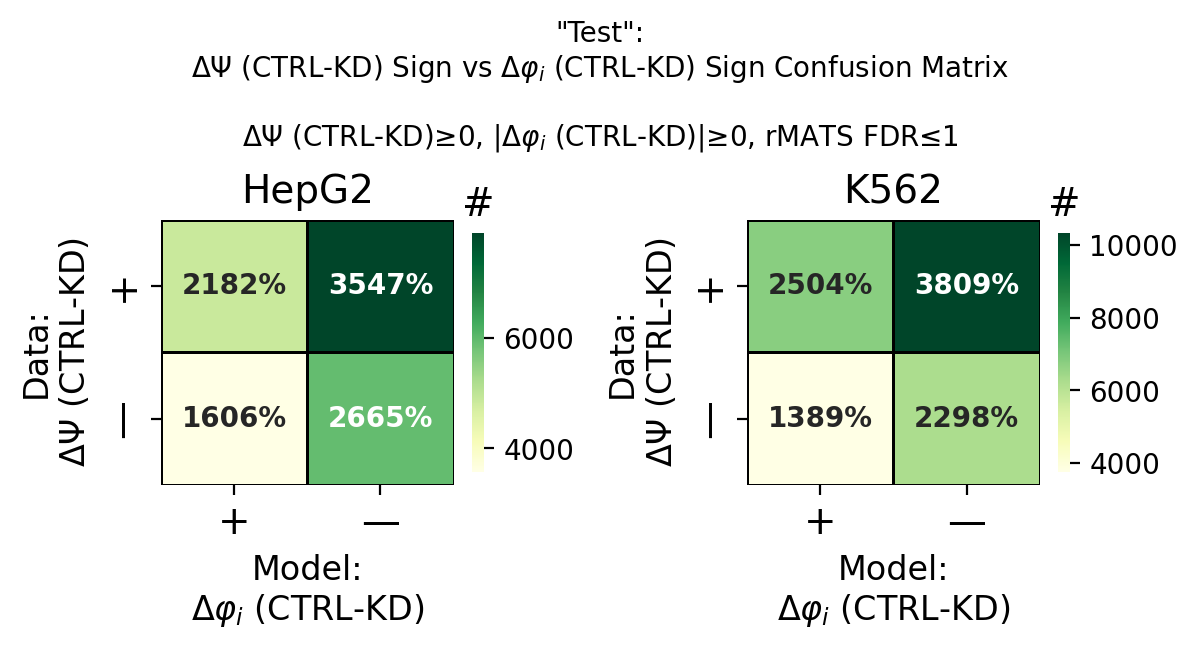

2025-10-08 15:14:09.851 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,23.112892,45.090180
—,8.216433,23.580494


2025-10-08 15:14:09.944 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,29.288538,52.332016
—,5.177866,13.201581


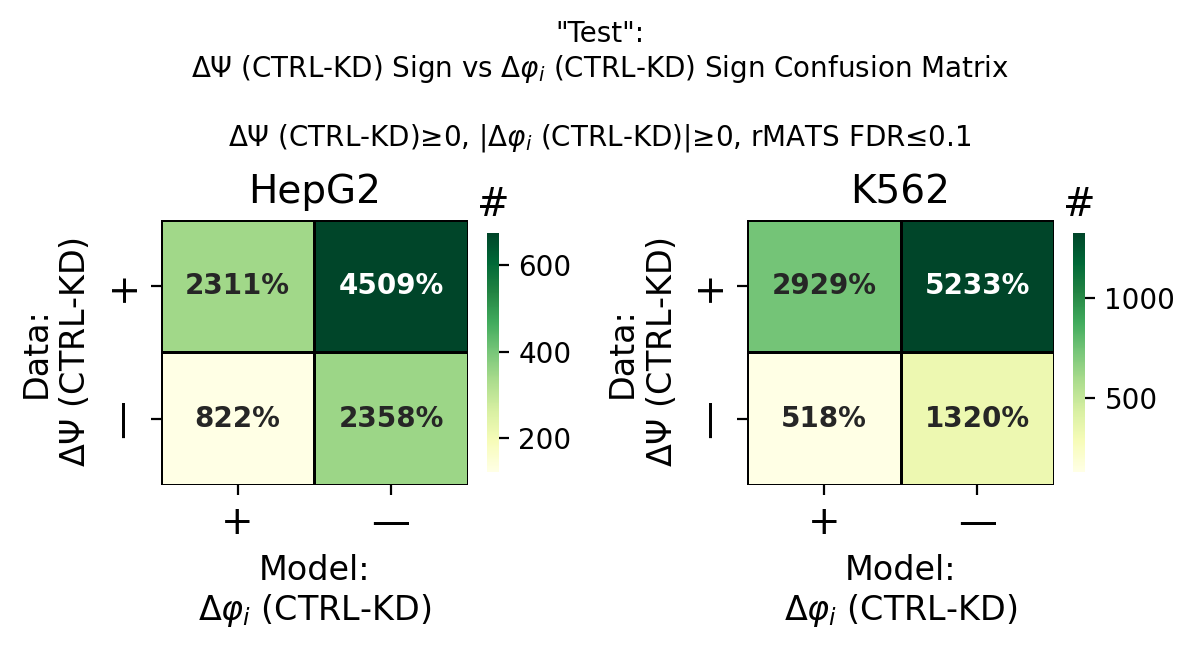

2025-10-08 15:14:10.301 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,23.421927,45.598007
—,7.225914,23.754153


2025-10-08 15:14:10.391 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,29.712163,53.621170
—,4.410399,12.256267


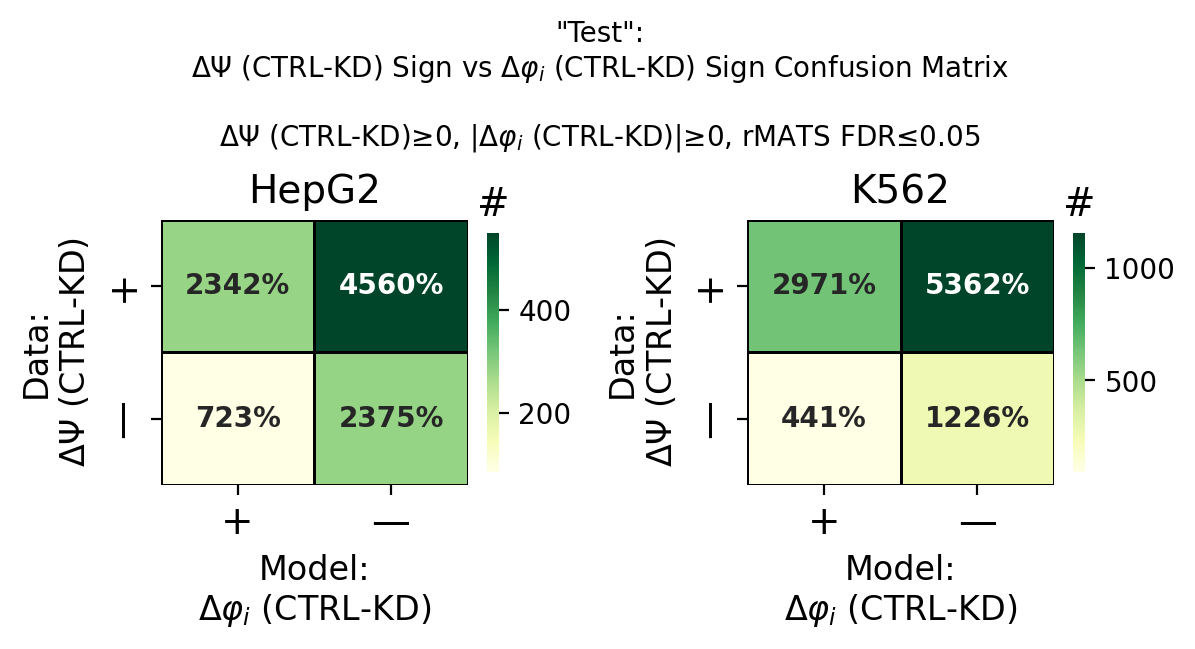

2025-10-08 15:14:10.868 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,21.947481,35.483871
—,16.315649,26.252999


2025-10-08 15:14:10.962 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,30.310927,34.33817
—,15.546343,19.80456


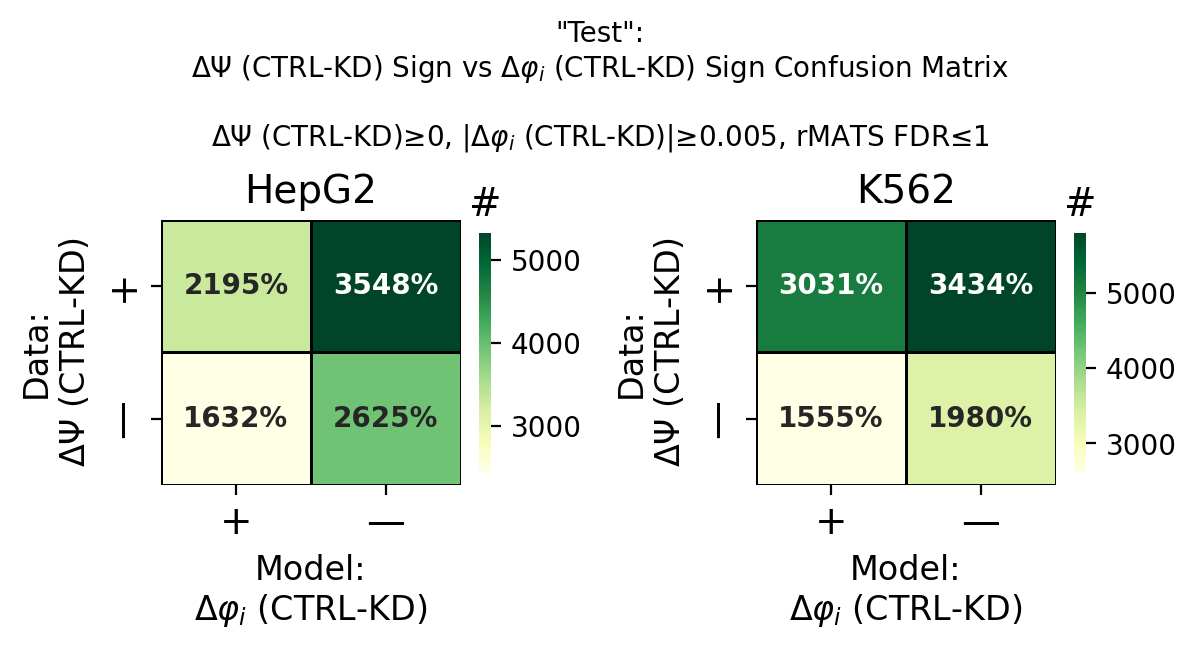

2025-10-08 15:14:11.319 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,19.845857,46.531792
—,6.647399,26.974952


2025-10-08 15:14:11.412 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,34.285714,48.742857
—,4.971429,12.000000


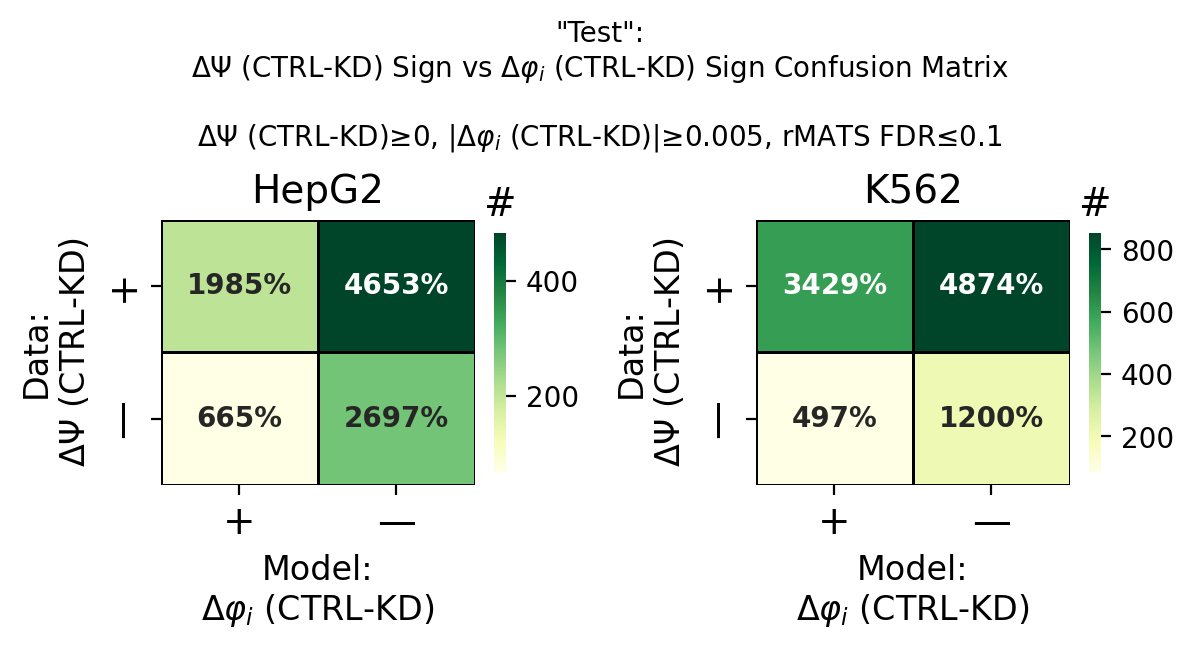

2025-10-08 15:14:11.773 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,19.927971,46.938776
—,6.002401,27.130852


2025-10-08 15:14:11.869 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,34.724983,49.900596
—,4.373757,11.000663


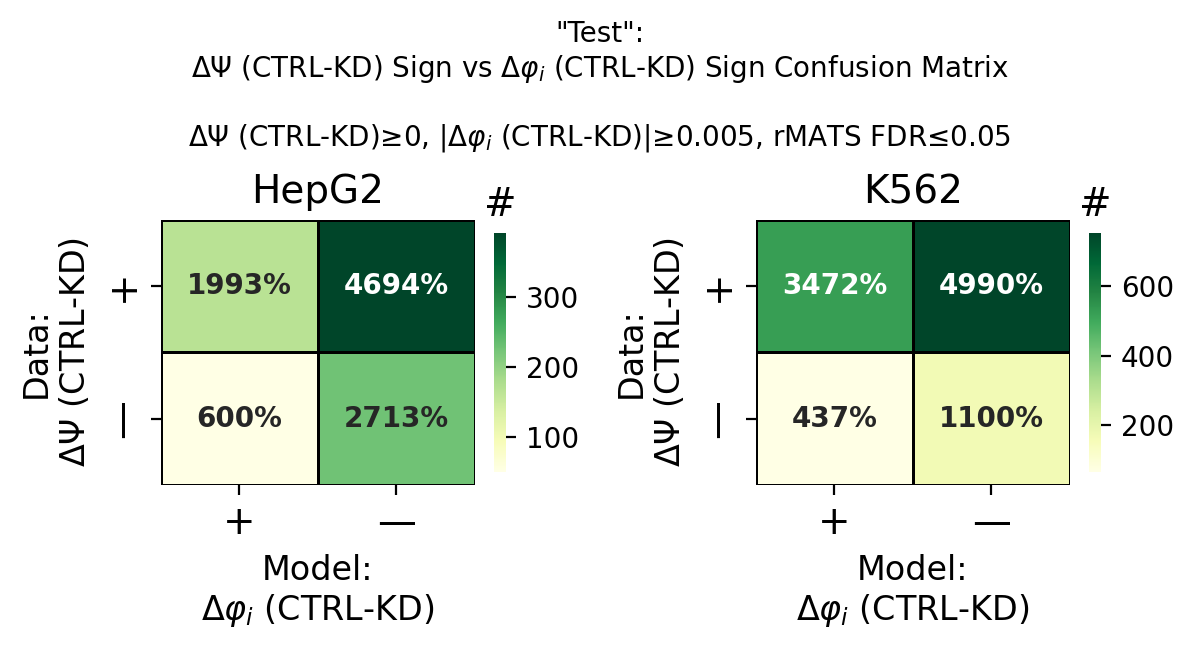

2025-10-08 15:14:12.237 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,25.377100,32.053480
—,18.957833,23.611587


2025-10-08 15:14:12.330 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,34.615100,30.532711
—,17.270505,17.581685


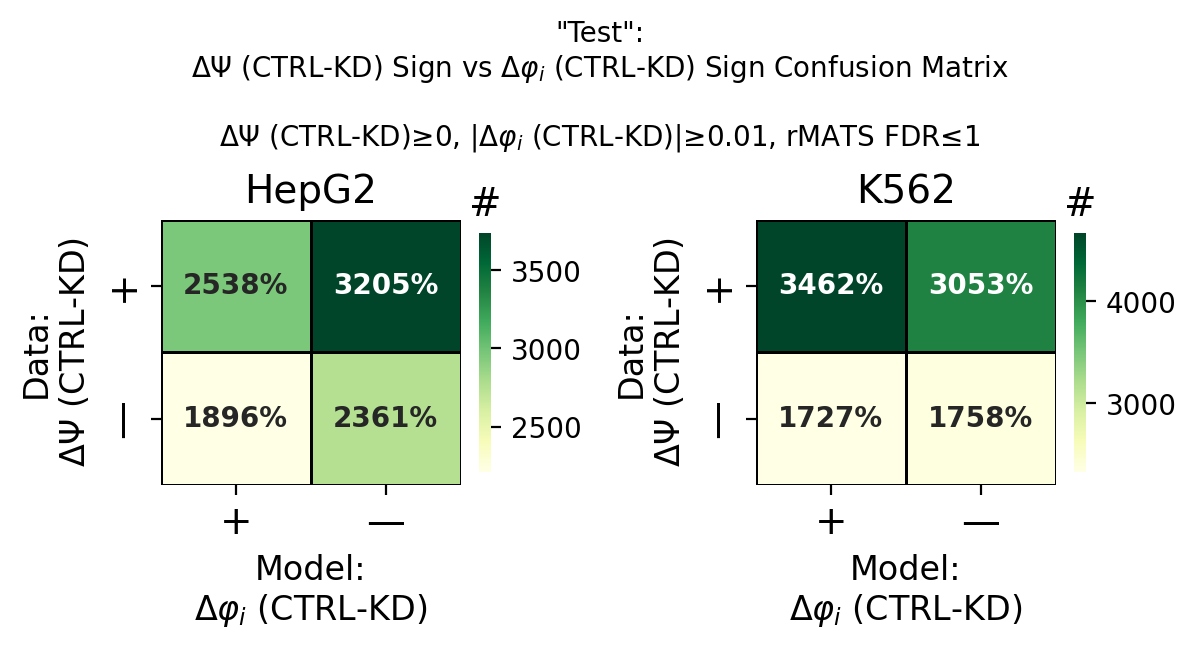

2025-10-08 15:14:12.688 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,20.488941,45.168801
—,7.450524,26.891735


2025-10-08 15:14:12.789 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,37.810611,45.802552
—,4.902619,11.484218


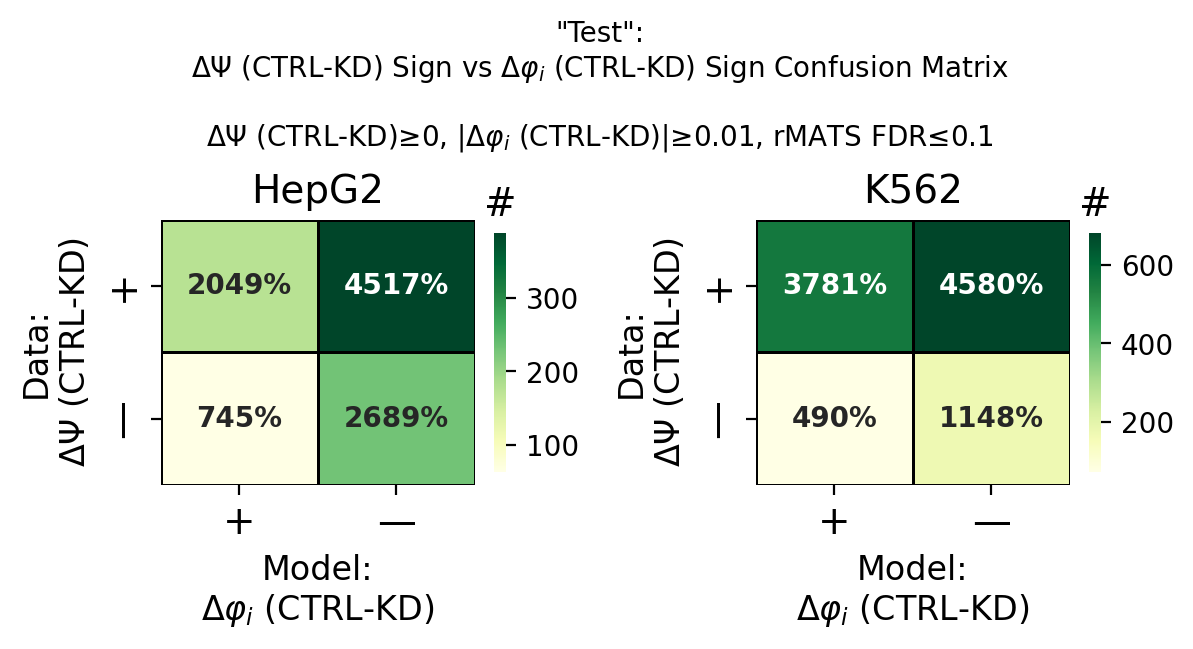

2025-10-08 15:14:13.156 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,20.341394,45.661451
—,6.827881,27.169275


2025-10-08 15:14:13.245 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,38.611544,46.723869
—,4.212168,10.452418


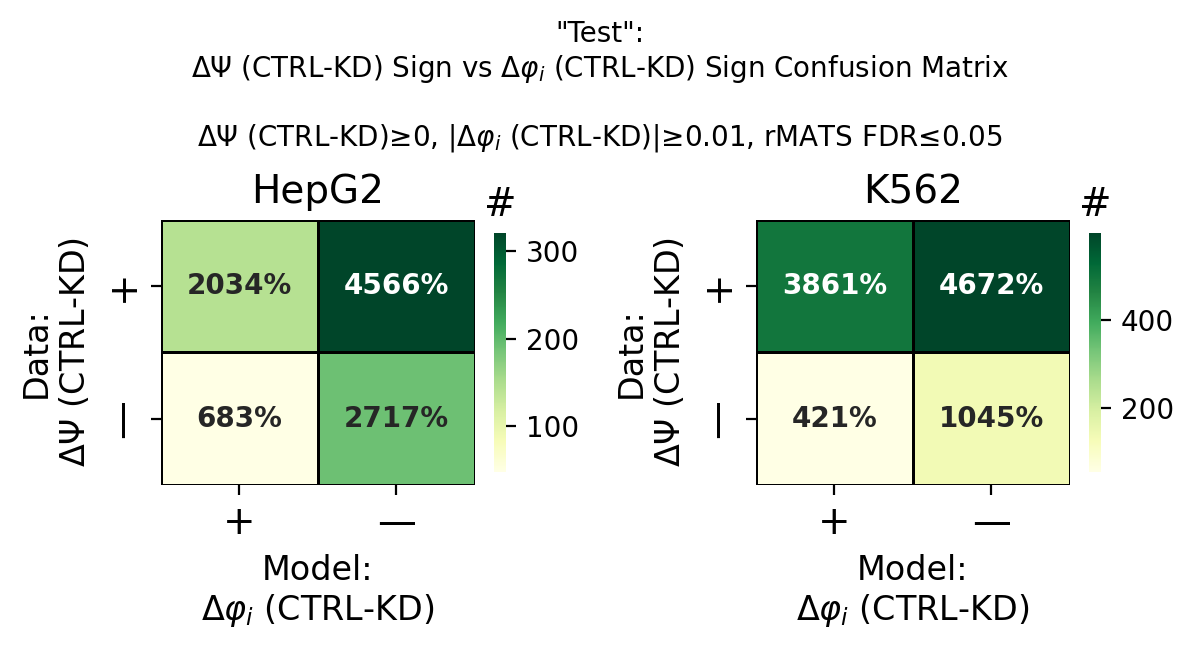

2025-10-08 15:14:13.602 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,41.609784,13.282139
—,33.560865,11.547213


2025-10-08 15:14:13.695 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,51.491457,13.871995
—,24.732117,9.904431


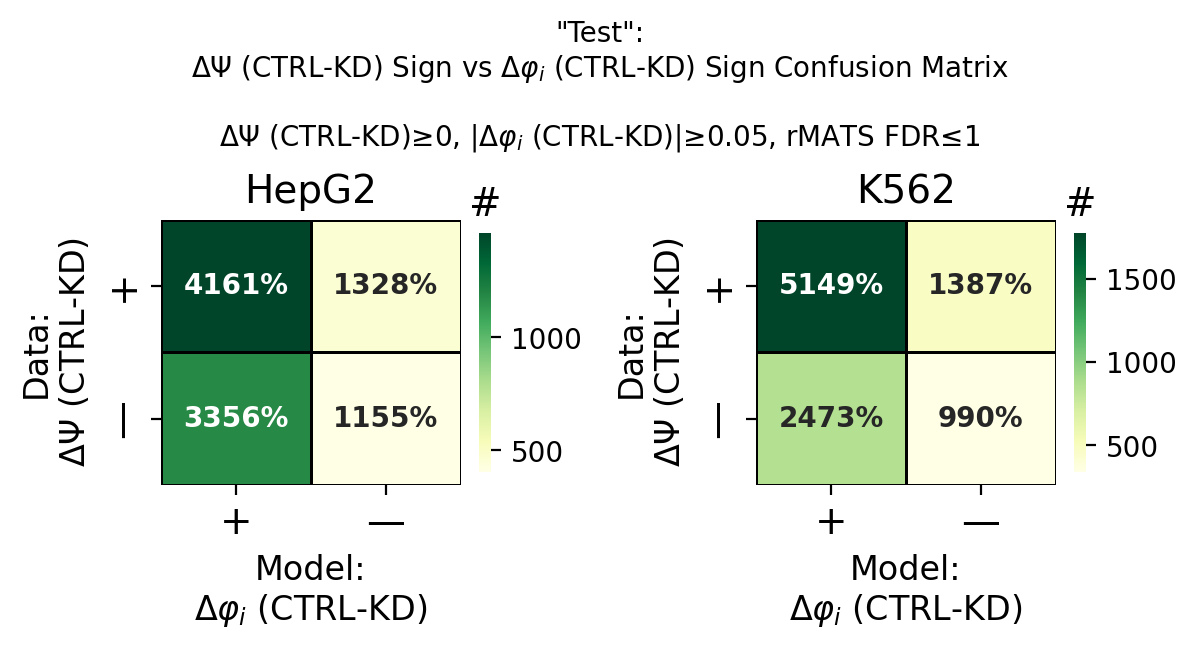

2025-10-08 15:14:14.237 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,33.928571,30.803571
—,8.035714,27.232143


2025-10-08 15:14:14.327 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,66.929134,16.010499
—,4.986877,12.073491


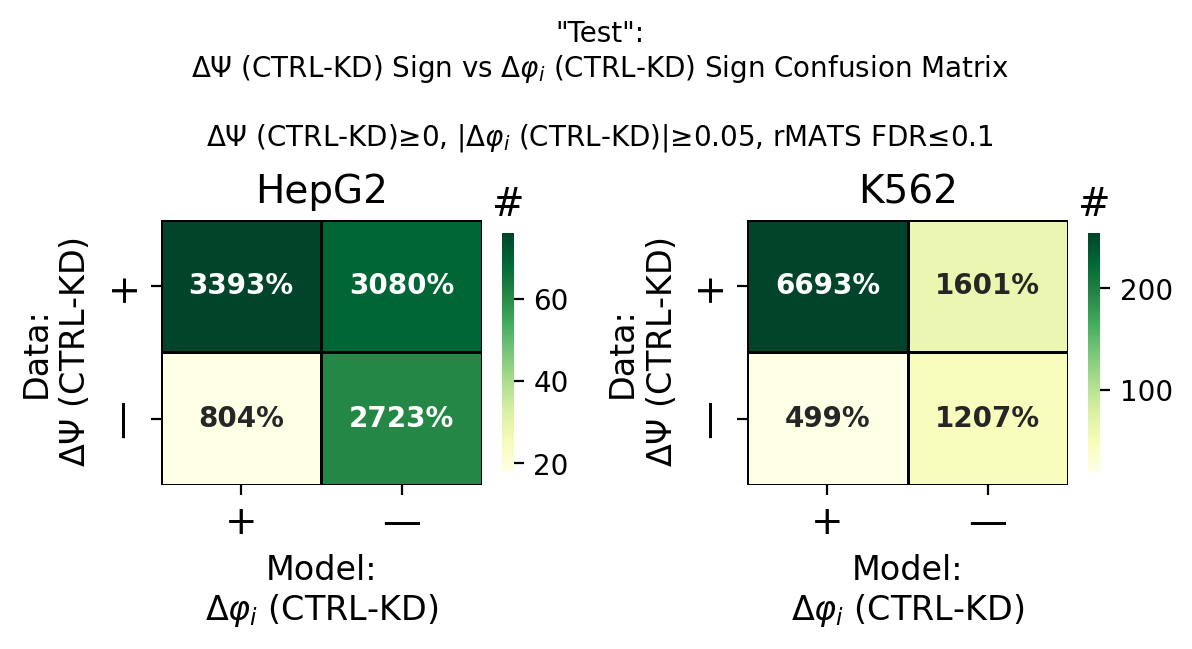

2025-10-08 15:14:14.681 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,31.182796,32.795699
—,6.989247,29.032258


2025-10-08 15:14:14.767 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,67.964072,14.670659
—,5.089820,12.275449


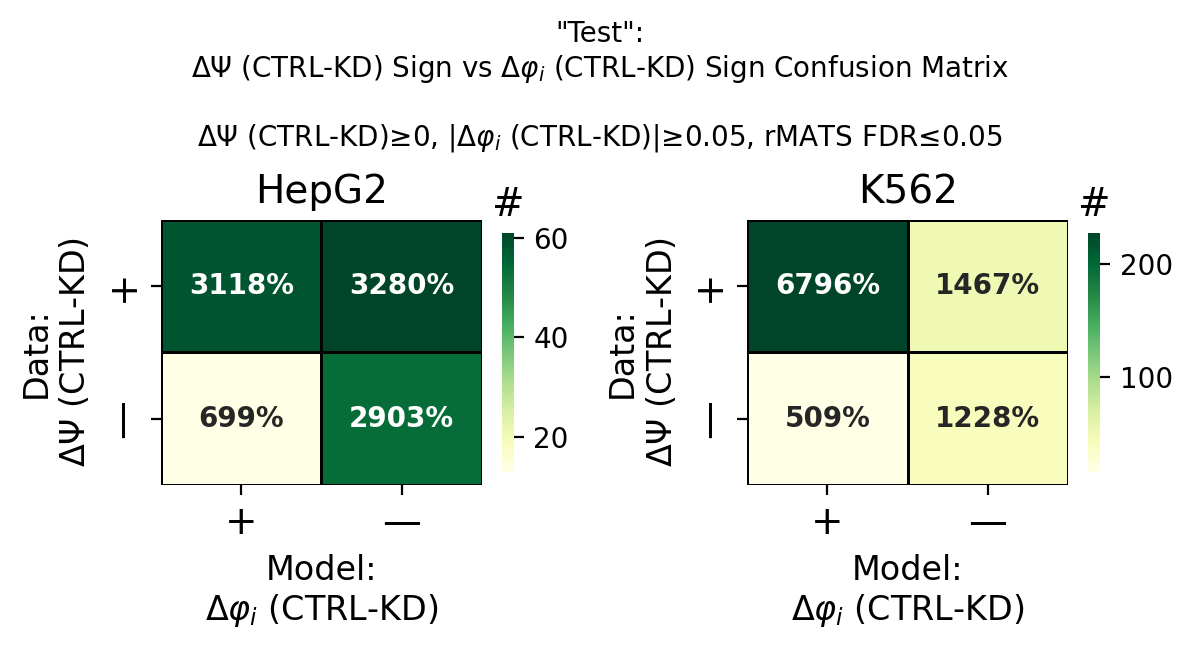

2025-10-08 15:14:15.125 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,20.954003,40.587734
—,11.925043,26.533220


2025-10-08 15:14:15.220 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,26.486838,48.423789
—,7.604810,17.484563


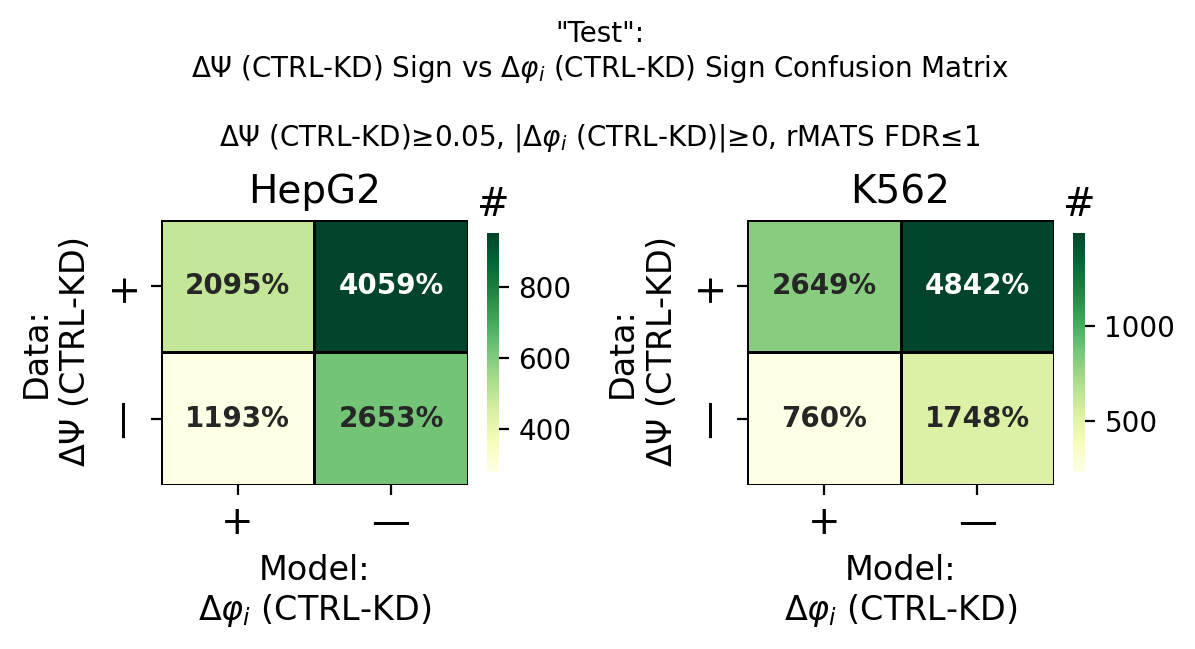

2025-10-08 15:14:15.575 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,22.394881,45.612431
—,7.861060,24.131627


2025-10-08 15:14:15.660 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,28.971963,53.037383
—,5.373832,12.616822


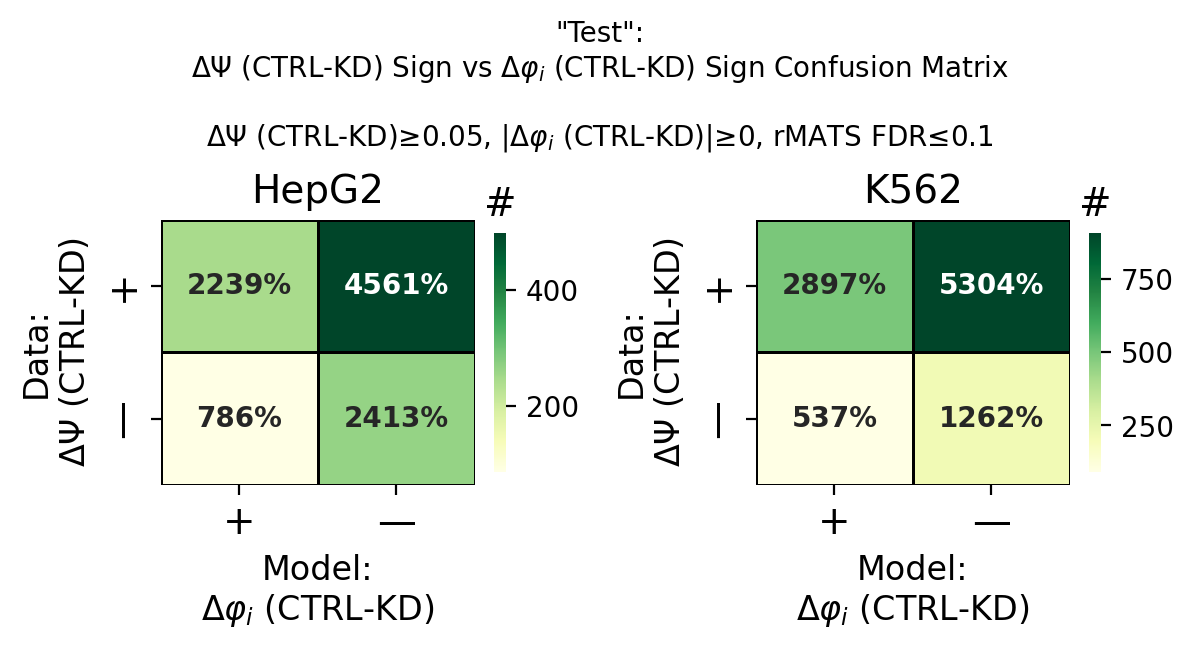

2025-10-08 15:14:16.020 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,23.101952,45.986985
—,7.158351,23.752711


2025-10-08 15:14:16.117 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,29.458388,54.293263
—,4.689564,11.558785


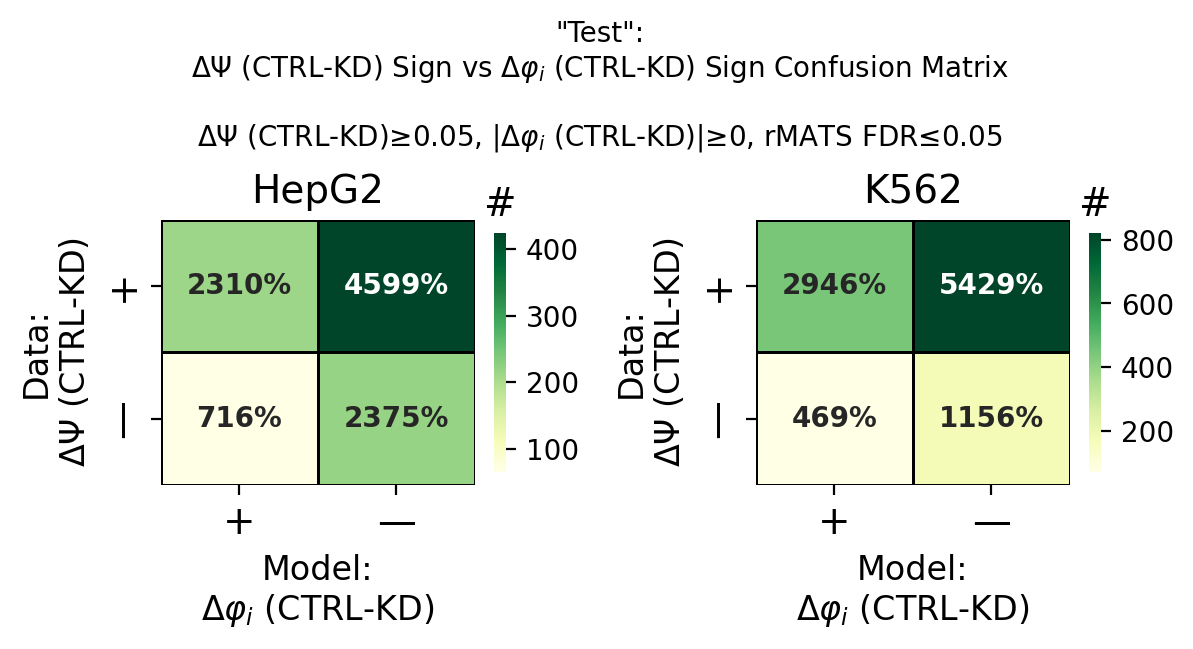

2025-10-08 15:14:16.483 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,17.885679,42.839582
—,10.141364,29.133374


2025-10-08 15:14:16.578 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,30.665333,45.322661
—,7.603802,16.408204


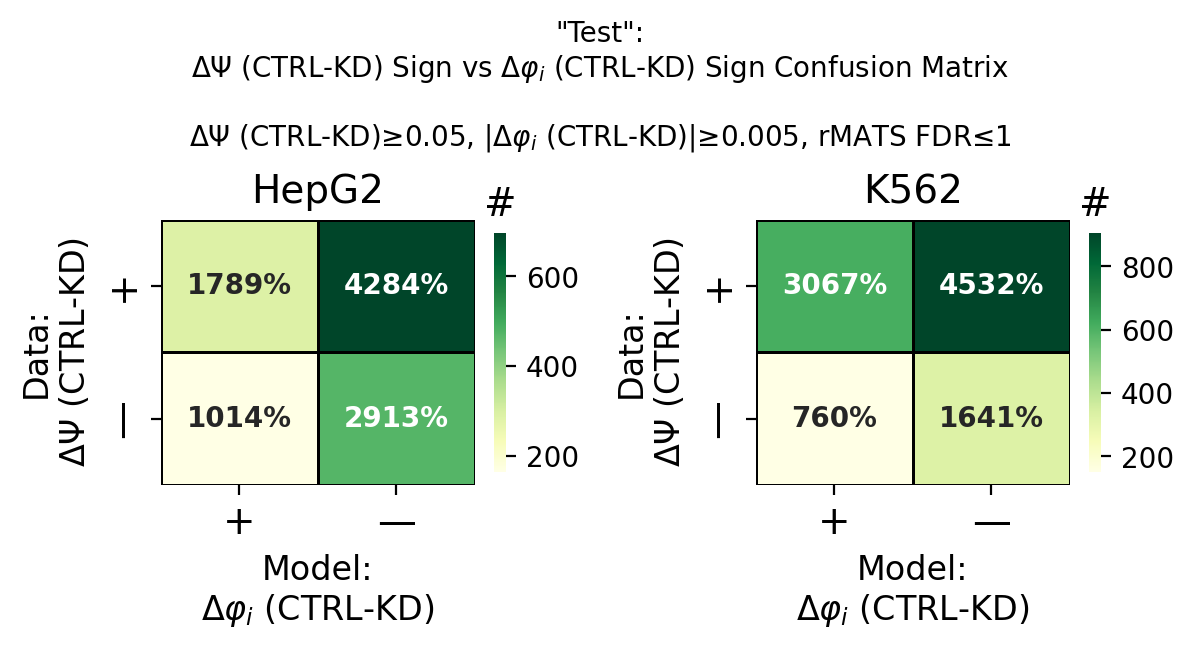

2025-10-08 15:14:17.115 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,18.378378,46.486486
—,6.486486,28.648649


2025-10-08 15:14:17.203 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,34.775233,48.600509
—,5.089059,11.535199


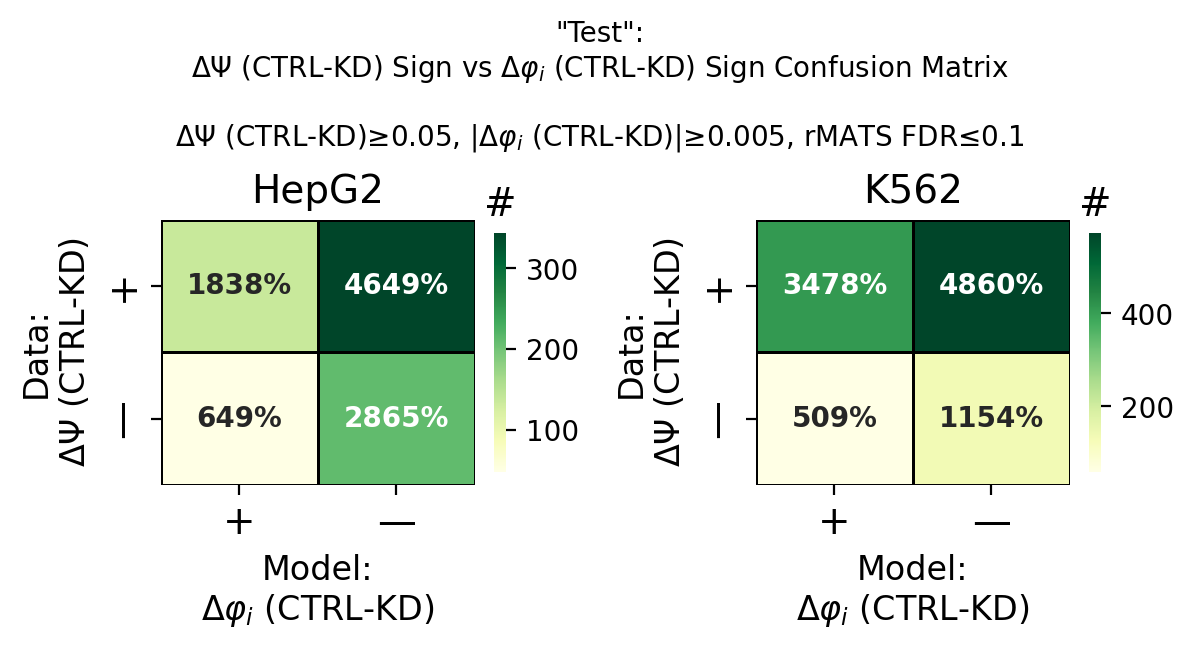

2025-10-08 15:14:17.556 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,18.940610,47.191011
—,6.099518,27.768860


2025-10-08 15:14:17.645 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,35.294118,49.715370
—,4.554080,10.436433


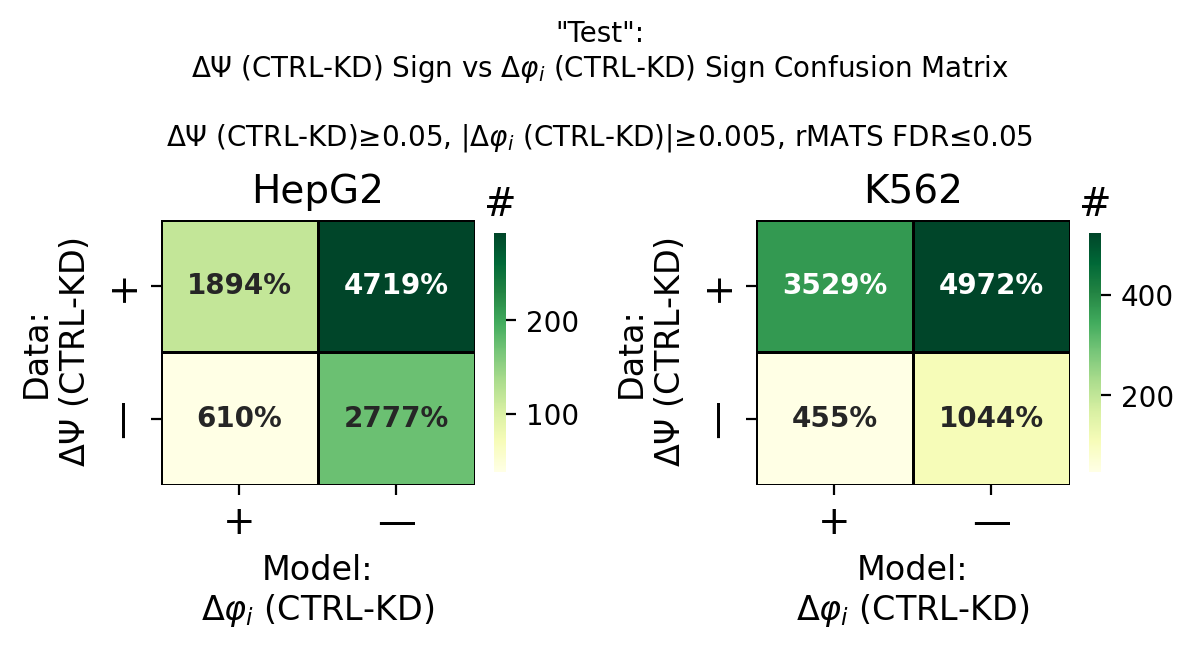

2025-10-08 15:14:17.995 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,18.594104,41.723356
—,10.657596,29.024943


2025-10-08 15:14:18.084 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,33.471564,43.305687
—,7.701422,15.521327


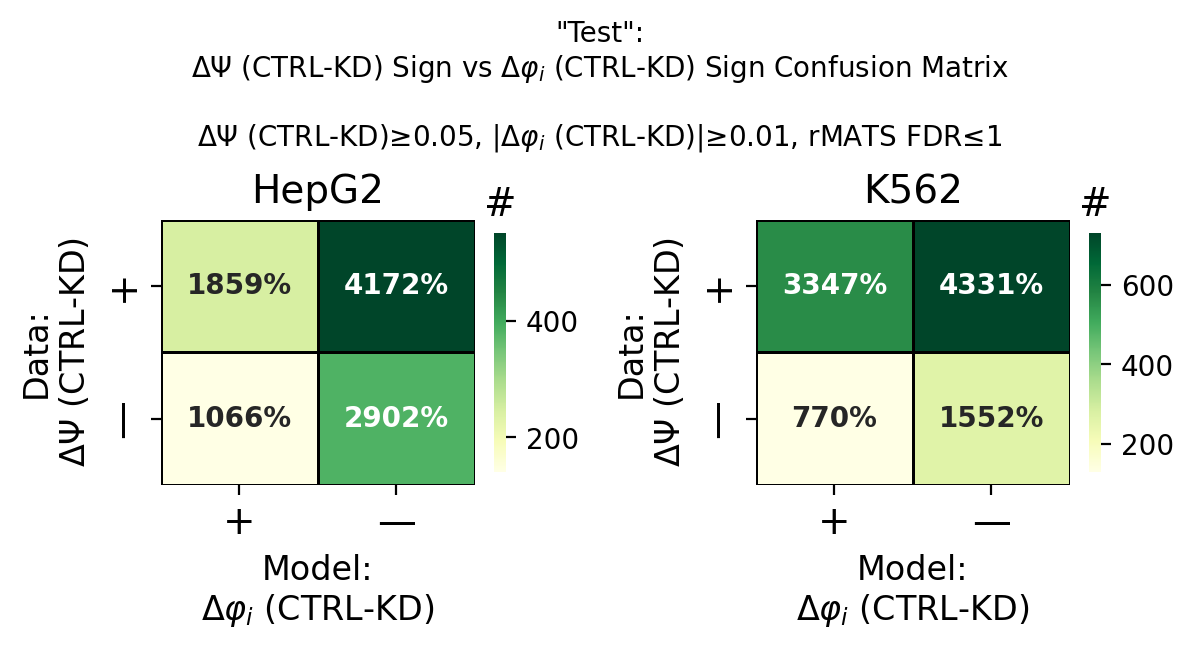

2025-10-08 15:14:18.438 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,18.241042,45.439739
—,7.003257,29.315961


2025-10-08 15:14:18.524 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,37.636544,46.077458
—,4.865938,11.420060


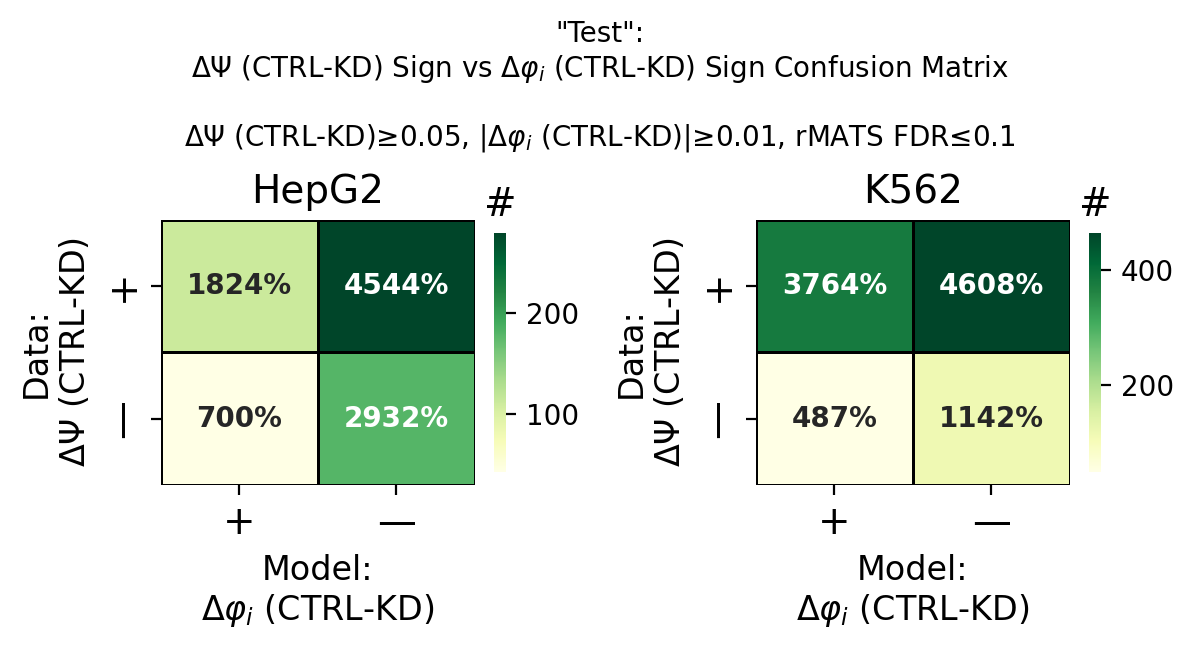

2025-10-08 15:14:18.872 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,18.525520,46.124764
—,6.805293,28.544423


2025-10-08 15:14:18.966 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,38.512764,46.947836
—,4.328524,10.210877


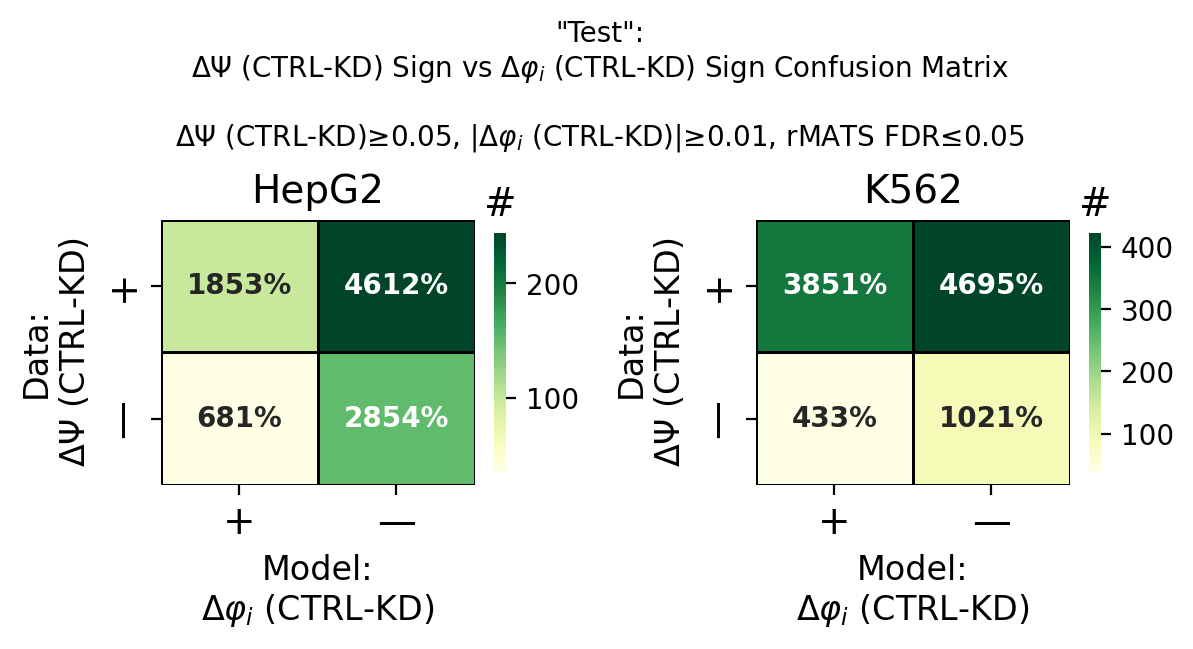

2025-10-08 15:14:19.331 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,32.712766,23.936170
—,20.212766,23.138298


2025-10-08 15:14:19.418 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,61.662818,15.704388
—,11.778291,10.854503


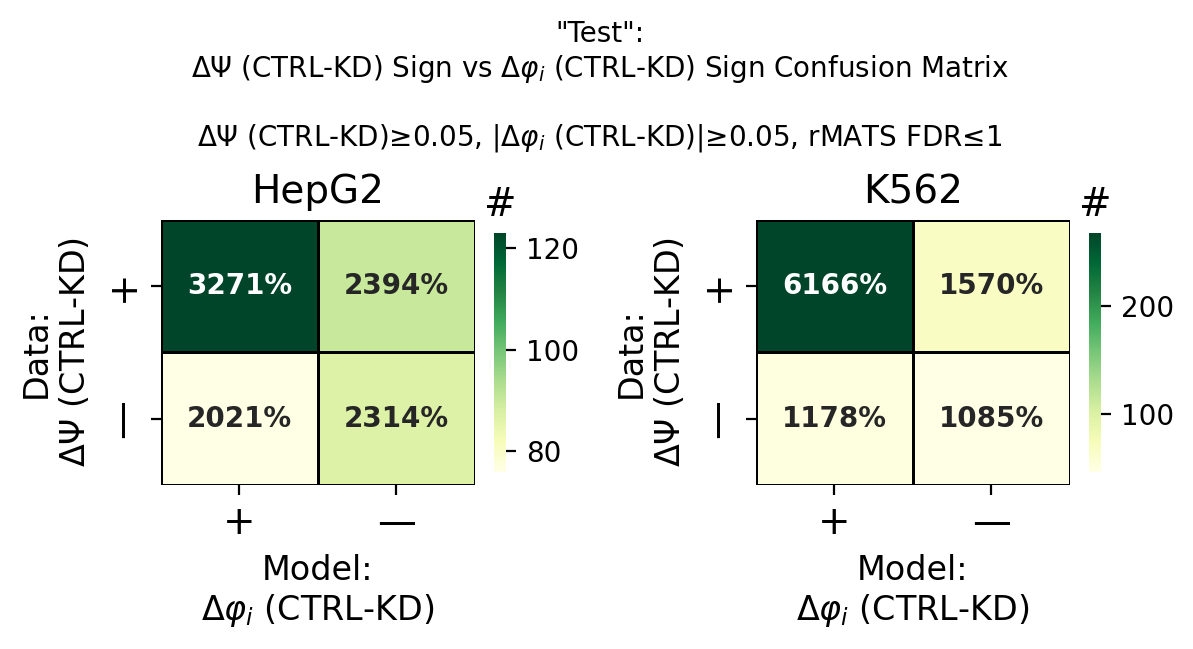

2025-10-08 15:14:19.776 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,28.205128,31.410256
—,8.974359,31.410256


2025-10-08 15:14:19.871 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,70.329670,12.820513
—,5.860806,10.989011


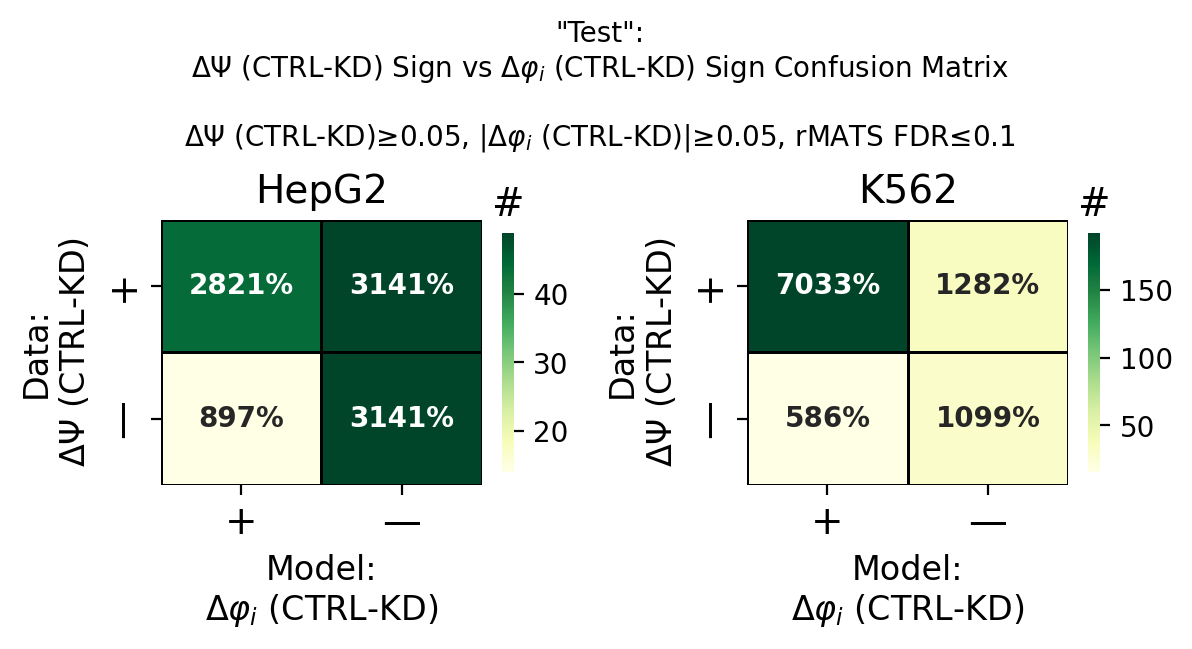

2025-10-08 15:14:20.396 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,25.547445,33.576642
—,8.029197,32.846715


2025-10-08 15:14:20.492 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,70.916335,12.749004
—,5.976096,10.358566


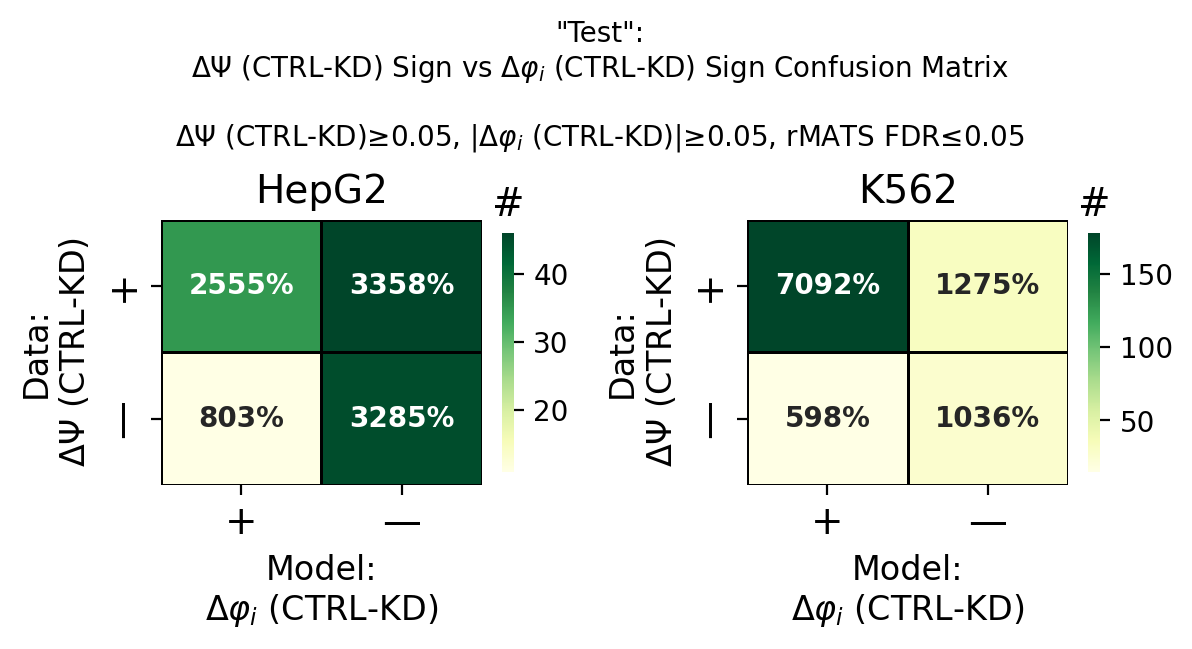

2025-10-08 15:14:20.855 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,21.245829,40.823137
—,10.678532,27.252503


2025-10-08 15:14:20.948 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,26.173429,50.437550
—,6.603023,16.785998


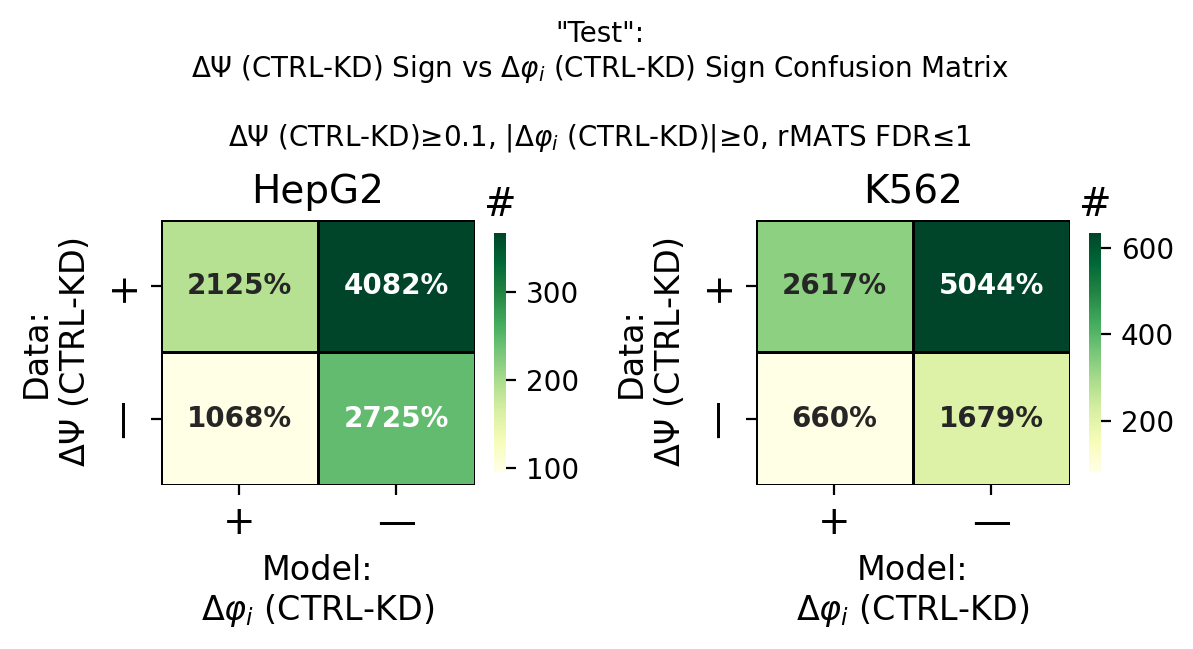

2025-10-08 15:14:21.306 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,22.720478,43.049327
—,8.968610,25.261584


2025-10-08 15:14:21.395 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,28.000000,53.578947
—,5.052632,13.368421


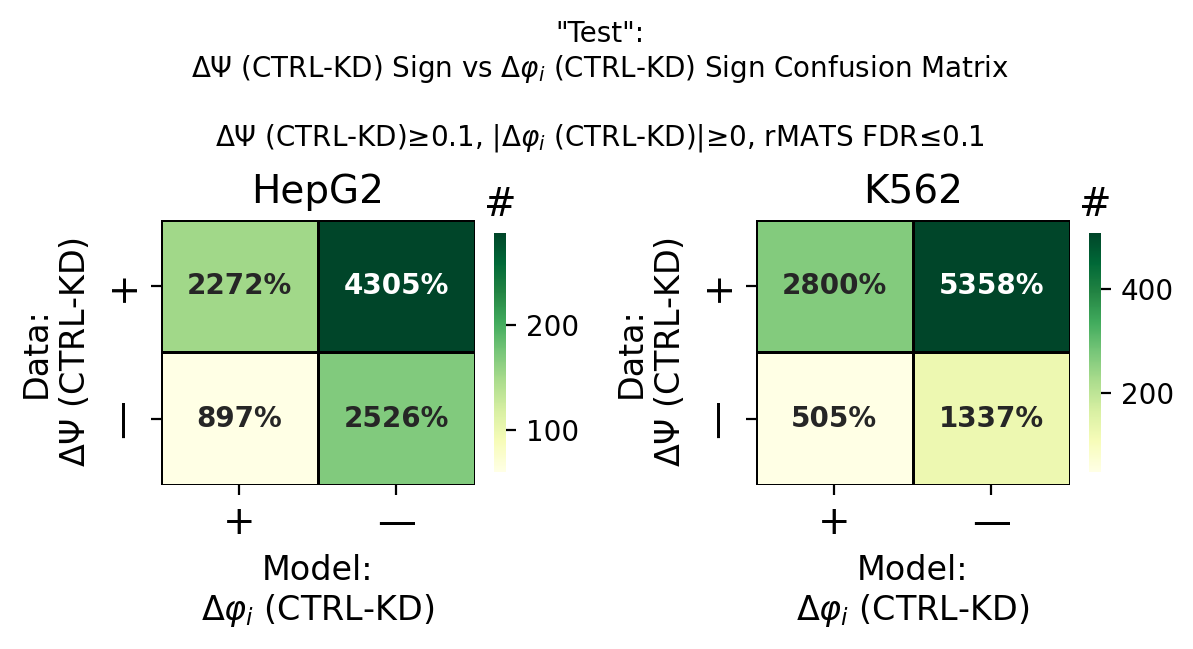

2025-10-08 15:14:21.745 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,23.178808,43.046358
—,8.278146,25.496689


2025-10-08 15:14:21.831 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,28.310502,53.881279
—,4.794521,13.013699


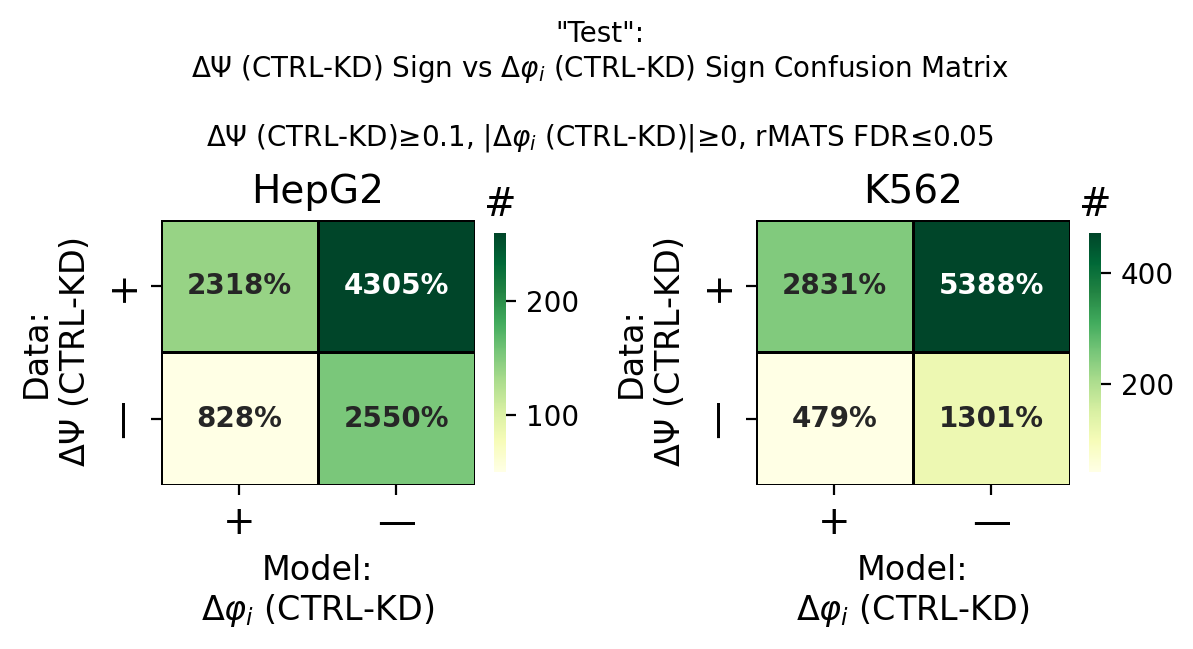

2025-10-08 15:14:22.181 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,17.363344,42.604502
—,8.681672,31.350482


2025-10-08 15:14:22.270 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,30.548926,47.732697
—,6.085919,15.632458


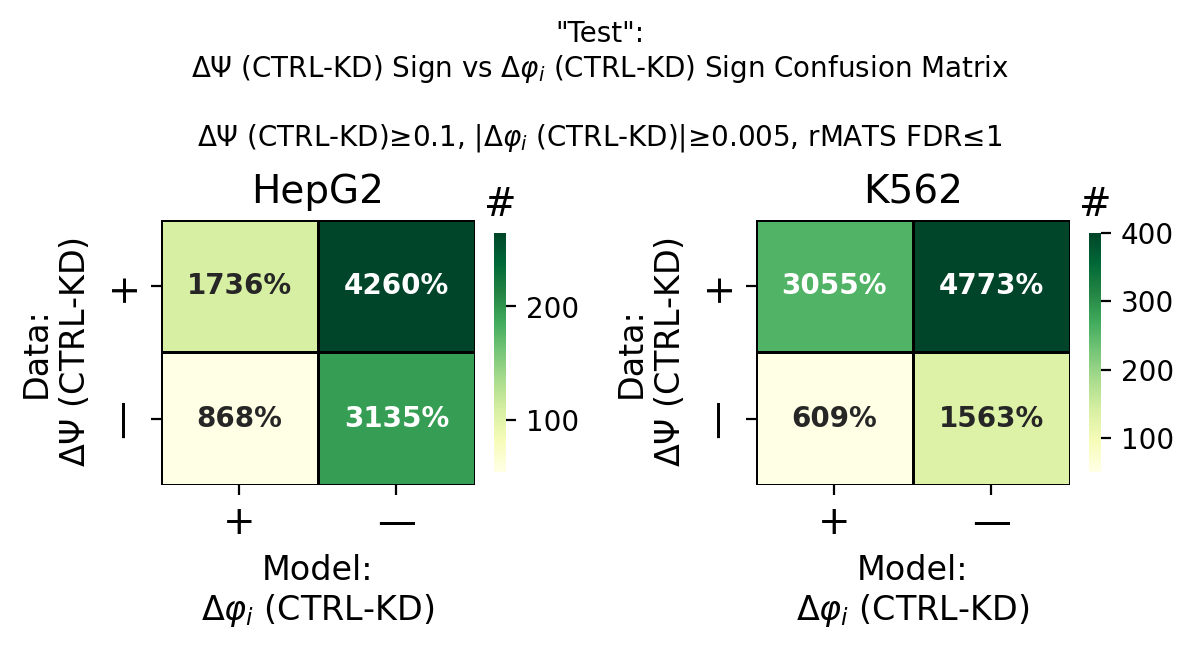

2025-10-08 15:14:22.632 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,17.841410,44.273128
—,7.048458,30.837004


2025-10-08 15:14:22.725 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,32.928680,50.379363
—,5.007587,11.684370


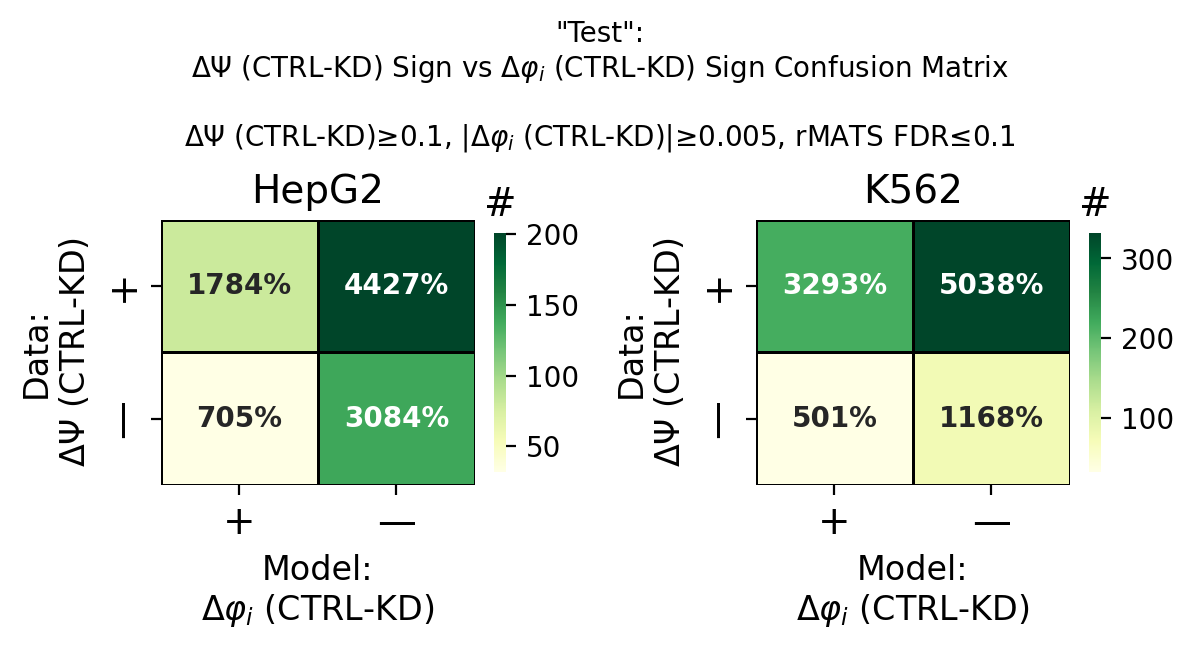

2025-10-08 15:14:23.093 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,17.761557,44.282238
—,6.812652,31.143552


2025-10-08 15:14:23.187 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,33.115824,50.734095
—,4.730832,11.419250


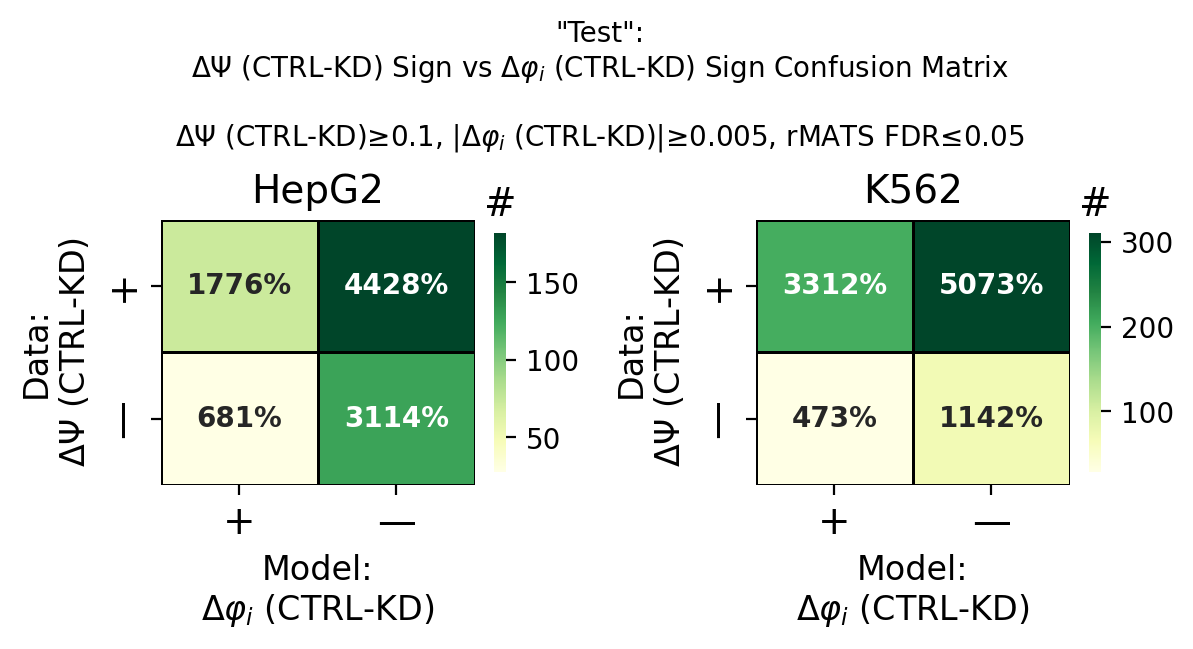

2025-10-08 15:14:23.720 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,16.988417,41.505792
—,8.687259,32.818533


2025-10-08 15:14:23.814 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,32.676056,45.774648
—,6.197183,15.352113


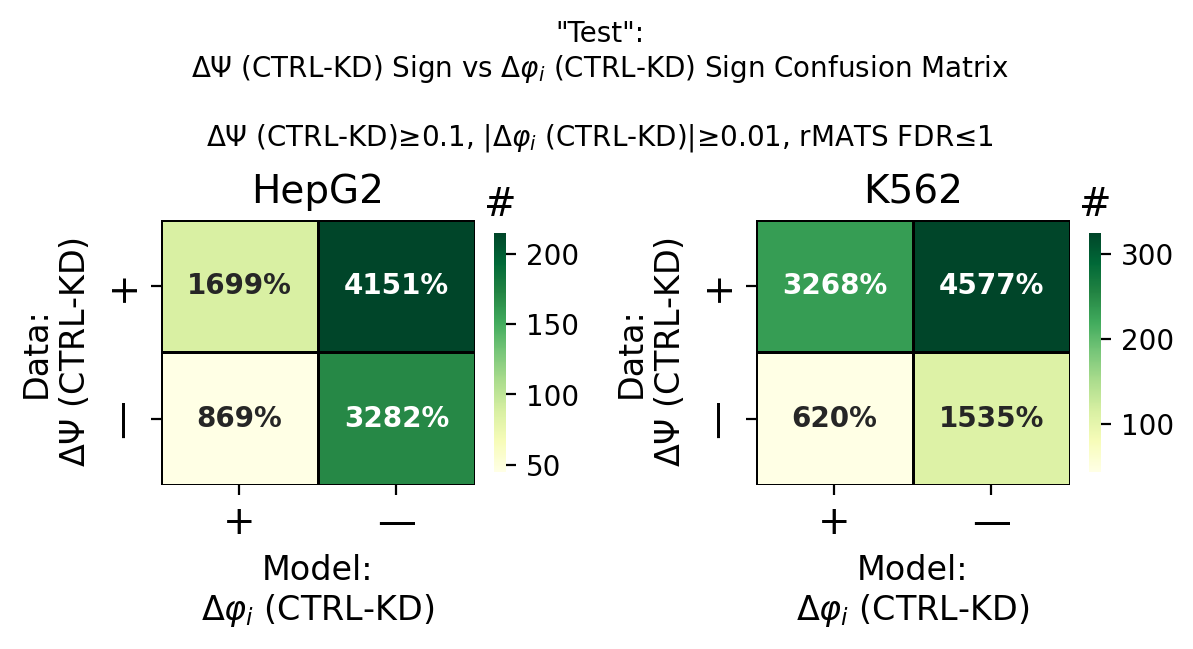

2025-10-08 15:14:24.181 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,17.447917,43.229167
—,7.812500,31.510417


2025-10-08 15:14:24.271 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,35.368043,47.935368
—,4.847397,11.849192


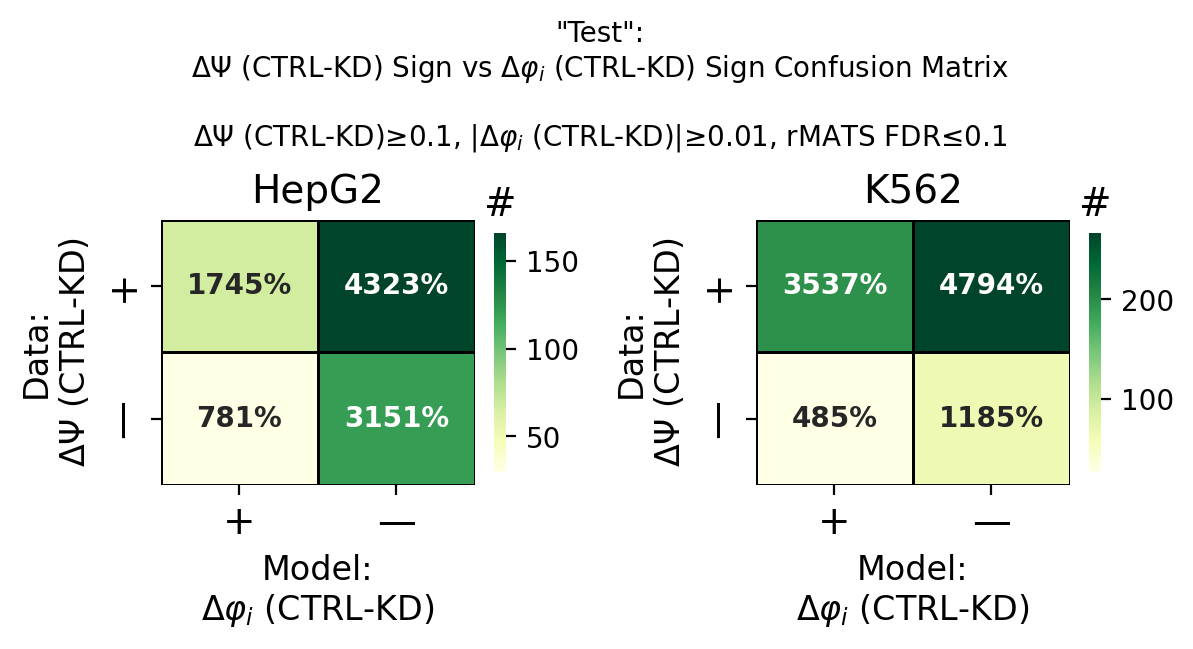

2025-10-08 15:14:24.628 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,17.183099,43.380282
—,7.605634,31.830986


2025-10-08 15:14:24.715 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,36.100386,47.876448
—,4.633205,11.389961


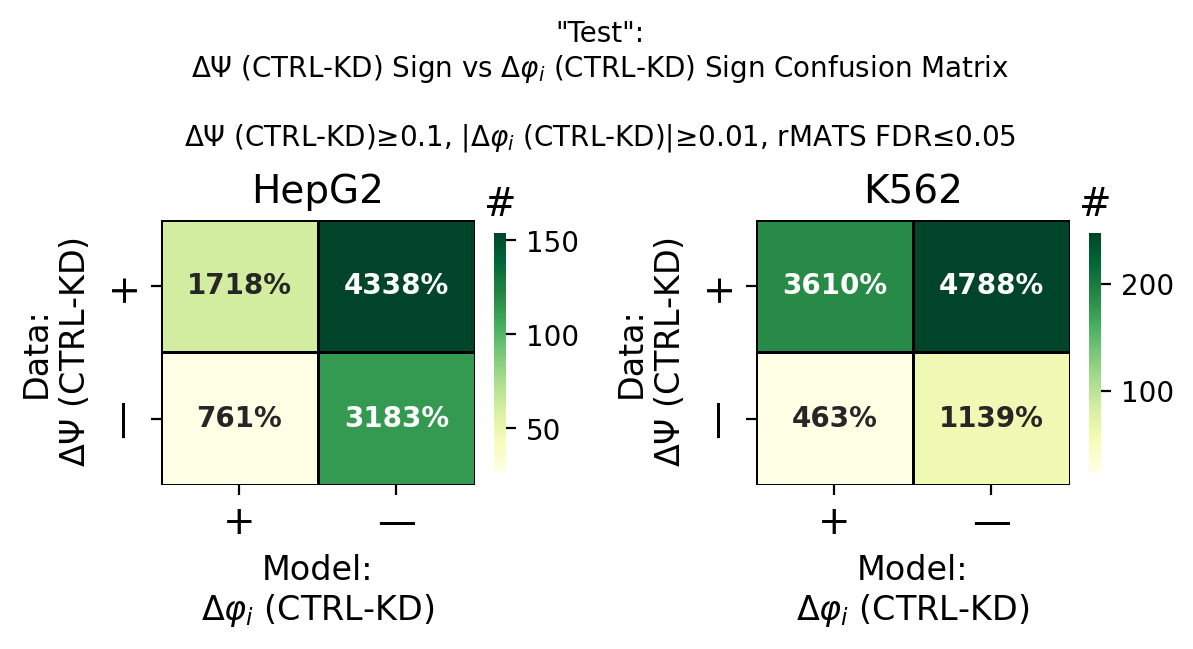

2025-10-08 15:14:25.067 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,26.896552,30.344828
—,12.413793,30.344828


2025-10-08 15:14:25.157 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,63.684211,16.315789
—,6.315789,13.684211


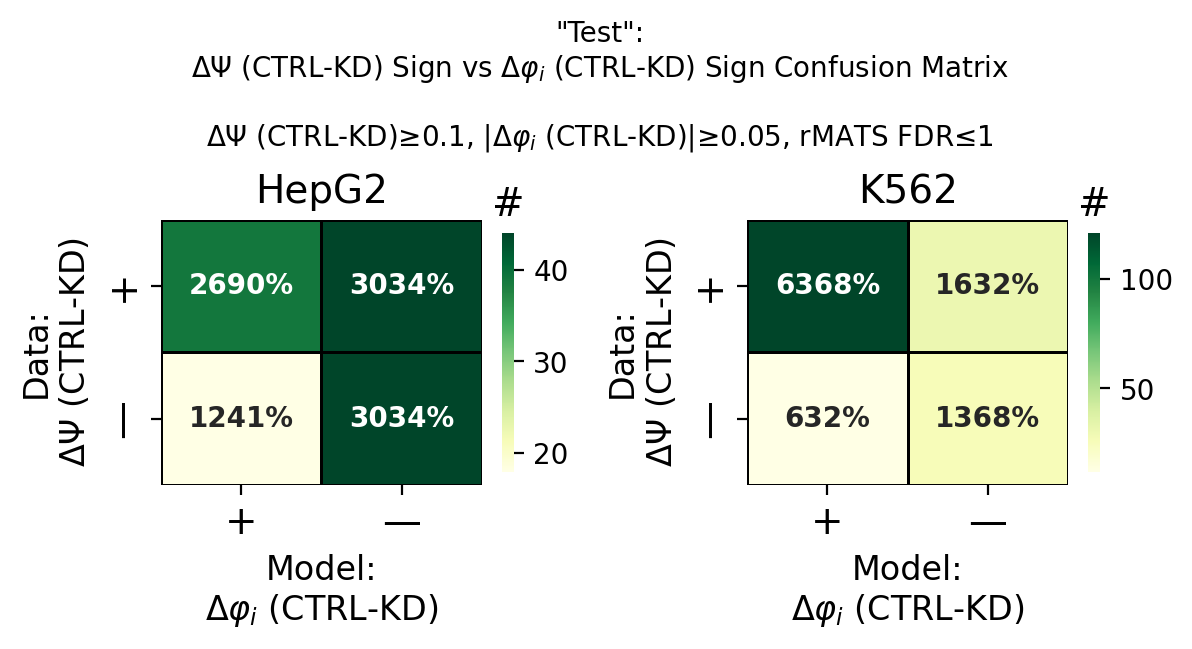

2025-10-08 15:14:25.523 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,26.363636,32.727273
—,10.000000,30.909091


2025-10-08 15:14:25.611 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,68.421053,14.473684
—,3.289474,13.815789


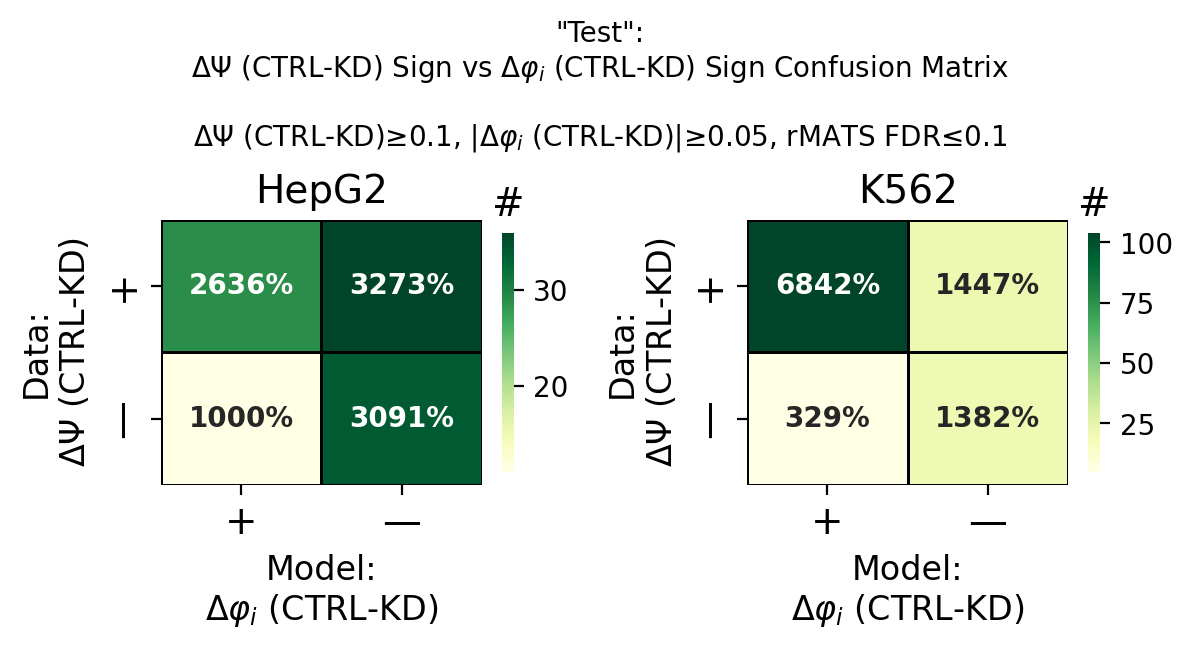

2025-10-08 15:14:25.970 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,23.529412,34.313725
—,9.803922,32.352941


2025-10-08 15:14:26.059 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,69.718310,13.380282
—,3.521127,13.380282


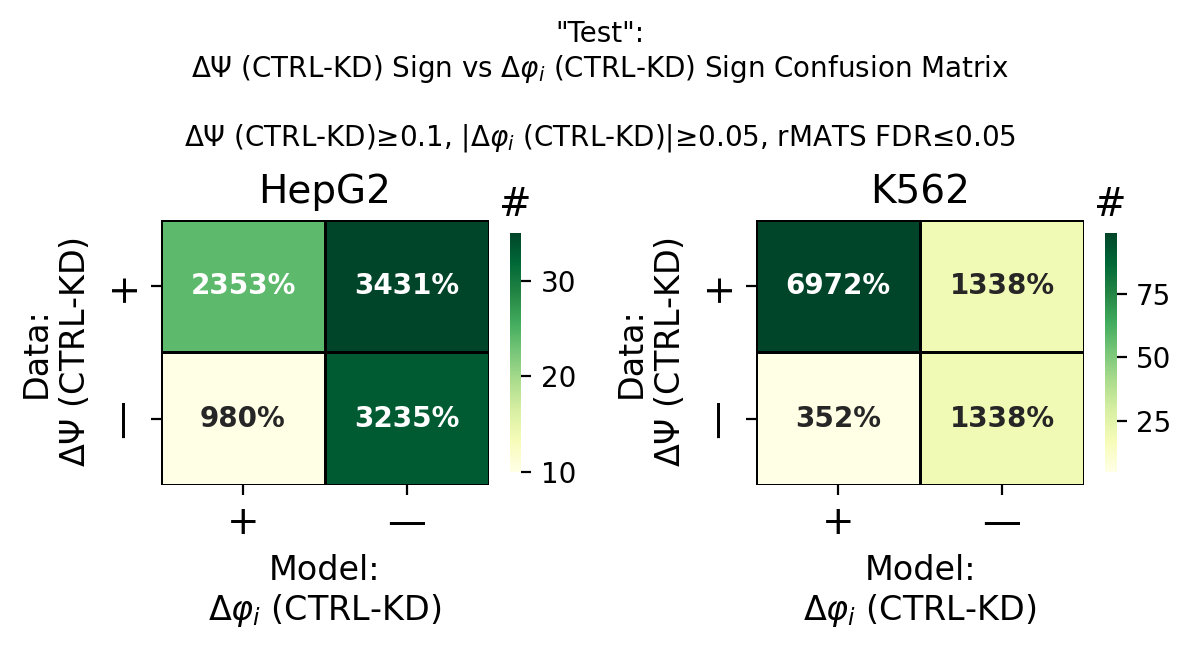

2025-10-08 15:14:26.716 | INFO     | 1_shap_network_analyzer:retrieve_differential_candidate_features:8361 - Retrieving CANDIDATE FEATURES w/
min_events=10, min_spearman=0.3, fishers_fdr=0.05 ...
2025-10-08 15:14:27.160 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,9.020066,52.152737
—,5.825054,33.002143


2025-10-08 15:14:27.254 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,4.557243,59.836977
—,1.852538,33.753242


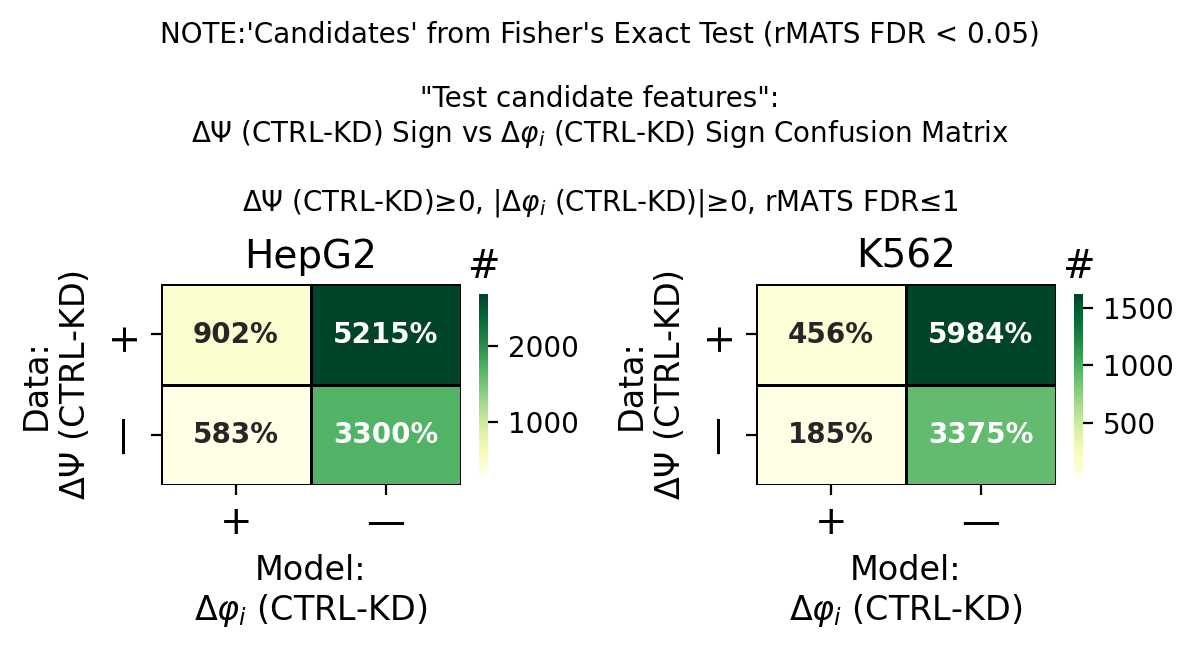

2025-10-08 15:14:27.626 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,11.827957,56.221198
—,6.298003,25.652842


2025-10-08 15:14:27.715 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,3.217822,79.455446
—,0.247525,17.079208


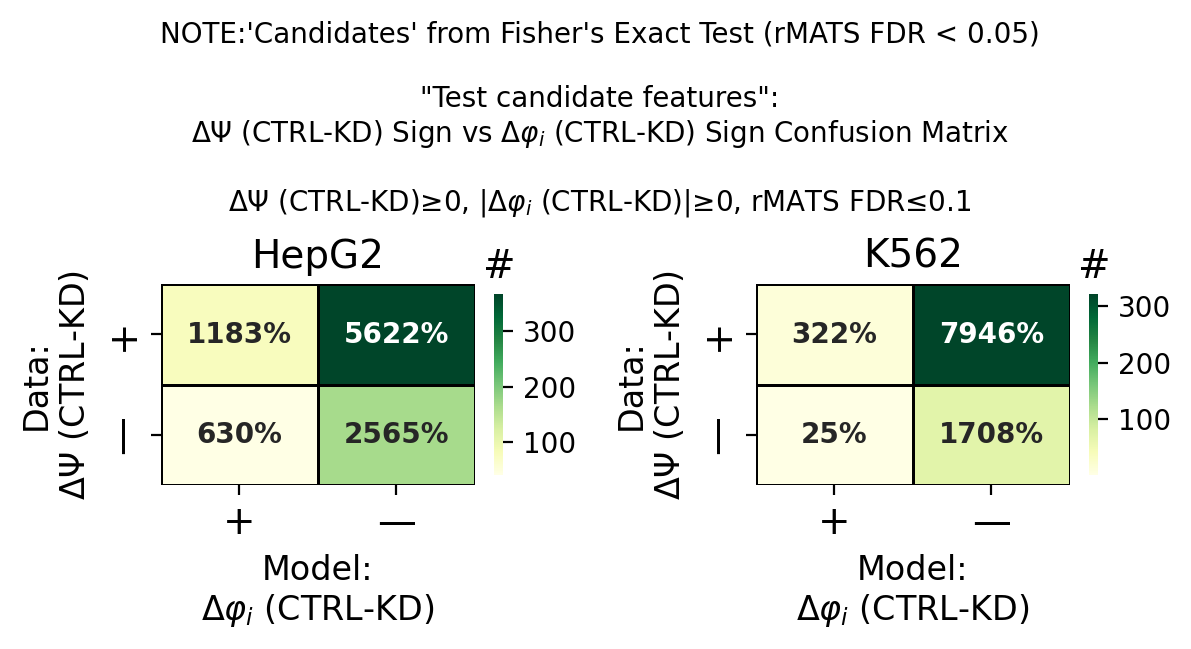

2025-10-08 15:14:28.090 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,12.365591,55.376344
—,6.451613,25.806452


2025-10-08 15:14:28.177 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,2.017291,83.285303
—,0.000000,14.697406


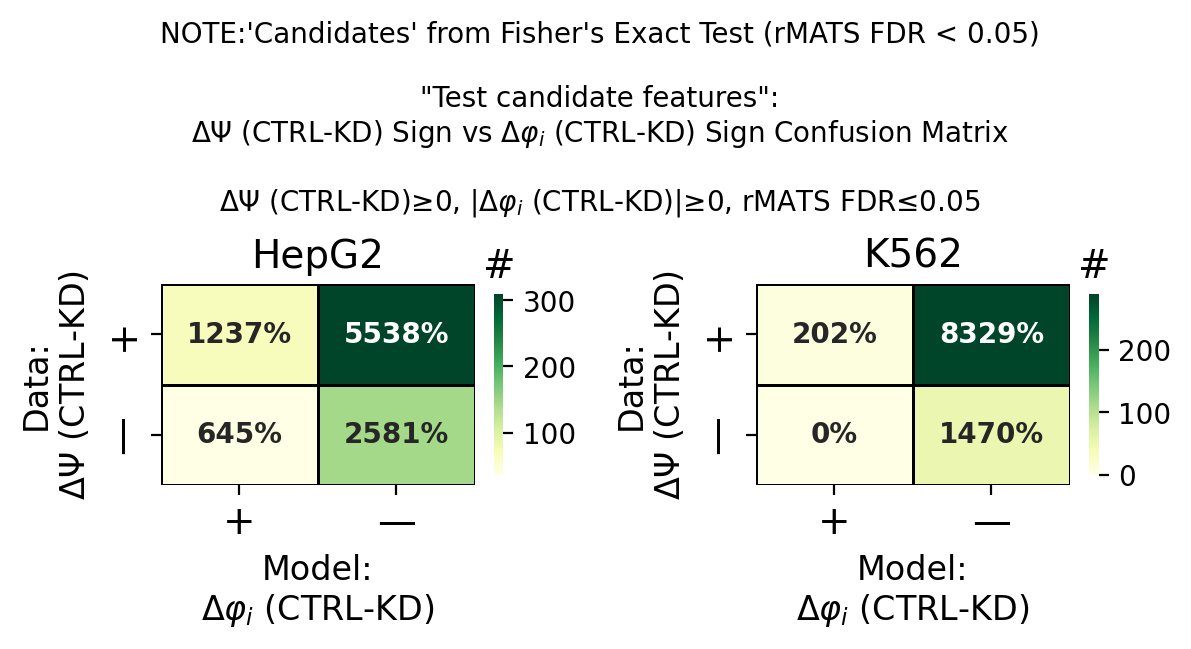

2025-10-08 15:14:28.546 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,4.050244,58.549090
—,1.794412,35.606255


2025-10-08 15:14:28.631 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,5.013774,60.826446
—,1.928375,32.231405


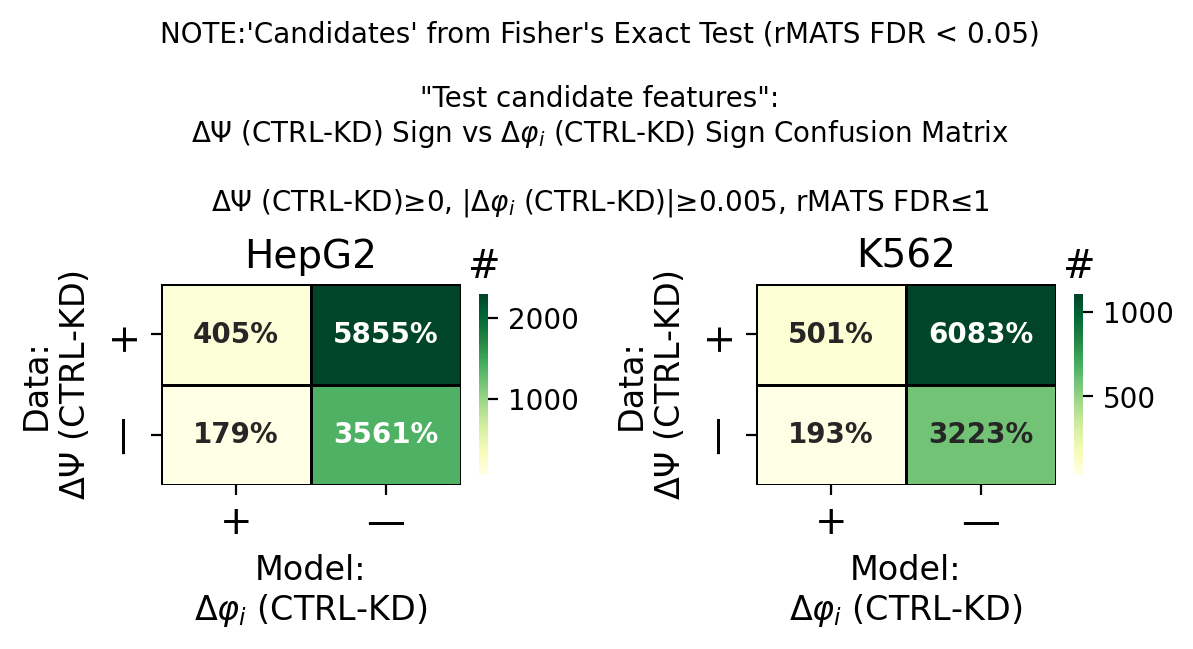

2025-10-08 15:14:28.995 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,7.678245,60.329068
—,4.936015,27.056673


2025-10-08 15:14:29.078 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,2.287582,80.065359
—,0.000000,17.647059


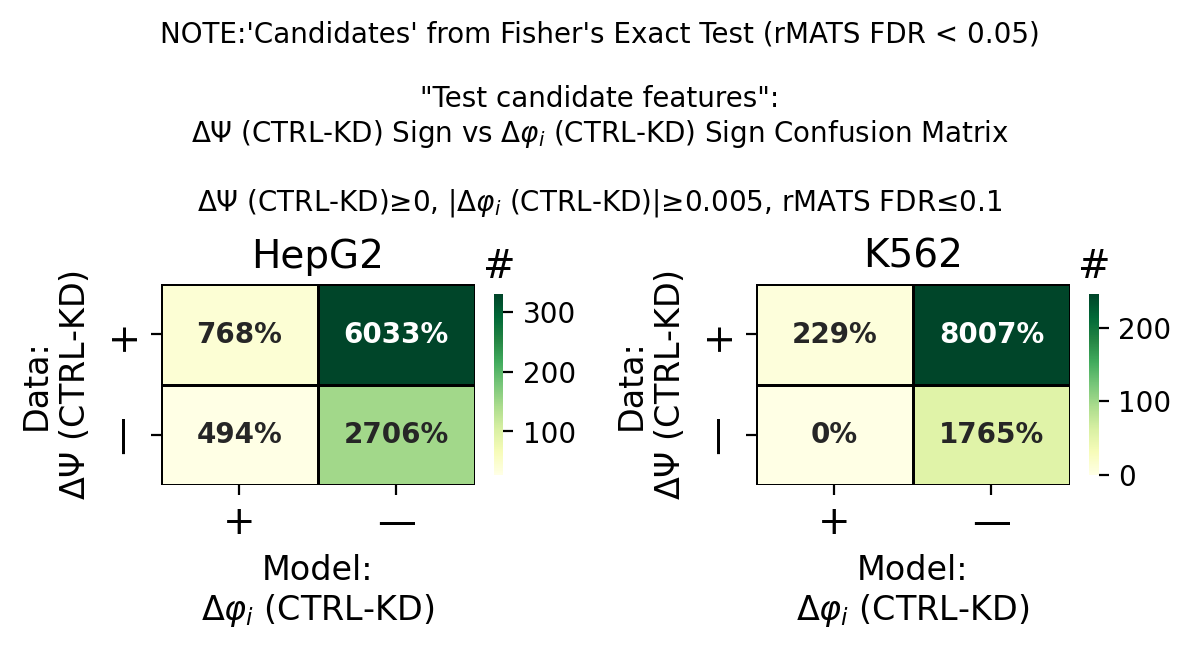

2025-10-08 15:14:29.447 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,8.297872,59.148936
—,5.531915,27.021277


2025-10-08 15:14:29.530 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,1.503759,83.082707
—,0.000000,15.413534


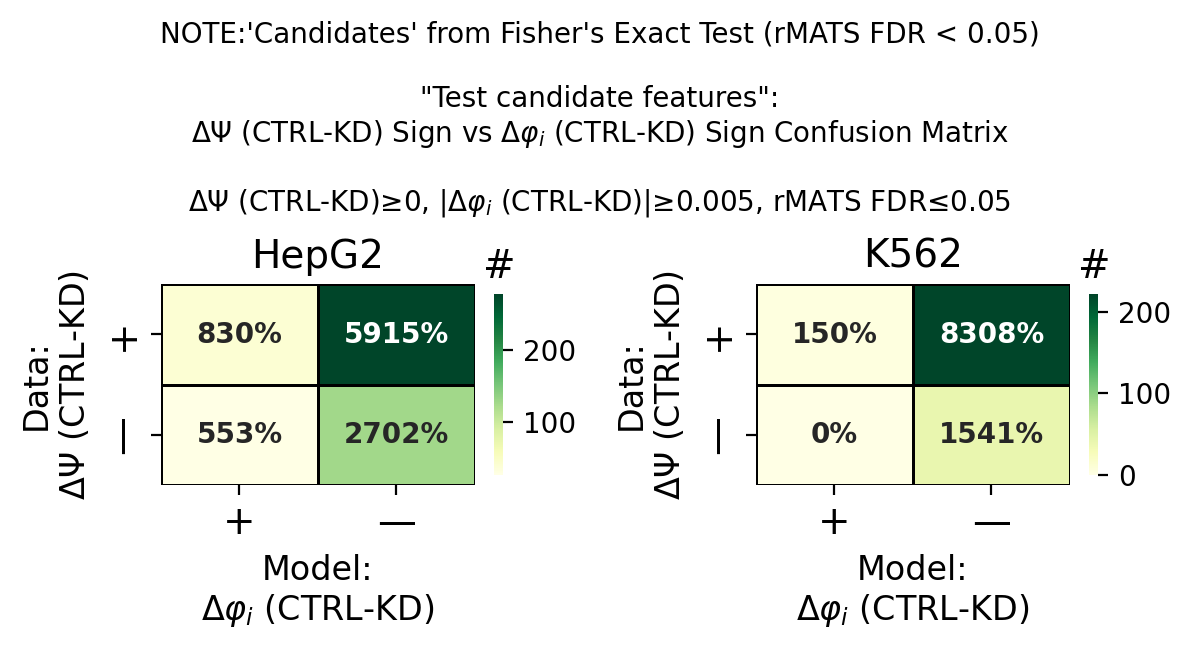

2025-10-08 15:14:29.898 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,3.685039,58.236220
—,1.952756,36.125984


2025-10-08 15:14:29.991 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,6.885508,56.765412
—,2.562050,33.787030


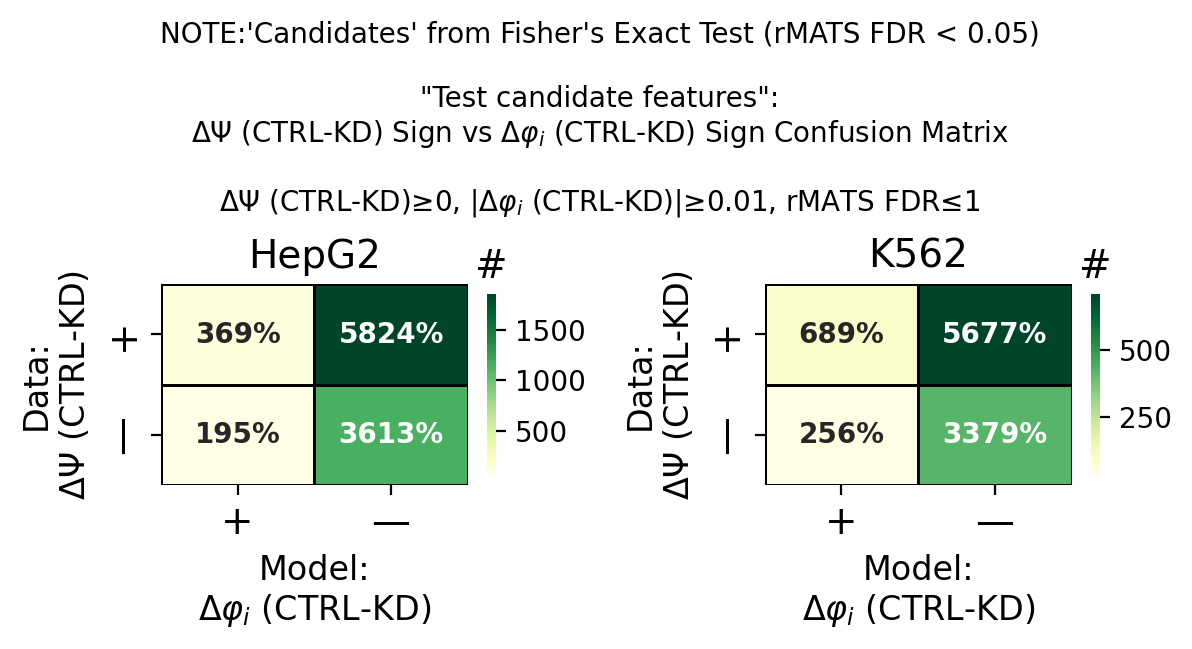

2025-10-08 15:14:30.529 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,6.790123,59.876543
—,5.349794,27.983539


2025-10-08 15:14:30.618 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,2.620087,78.165939
—,0.000000,19.213974


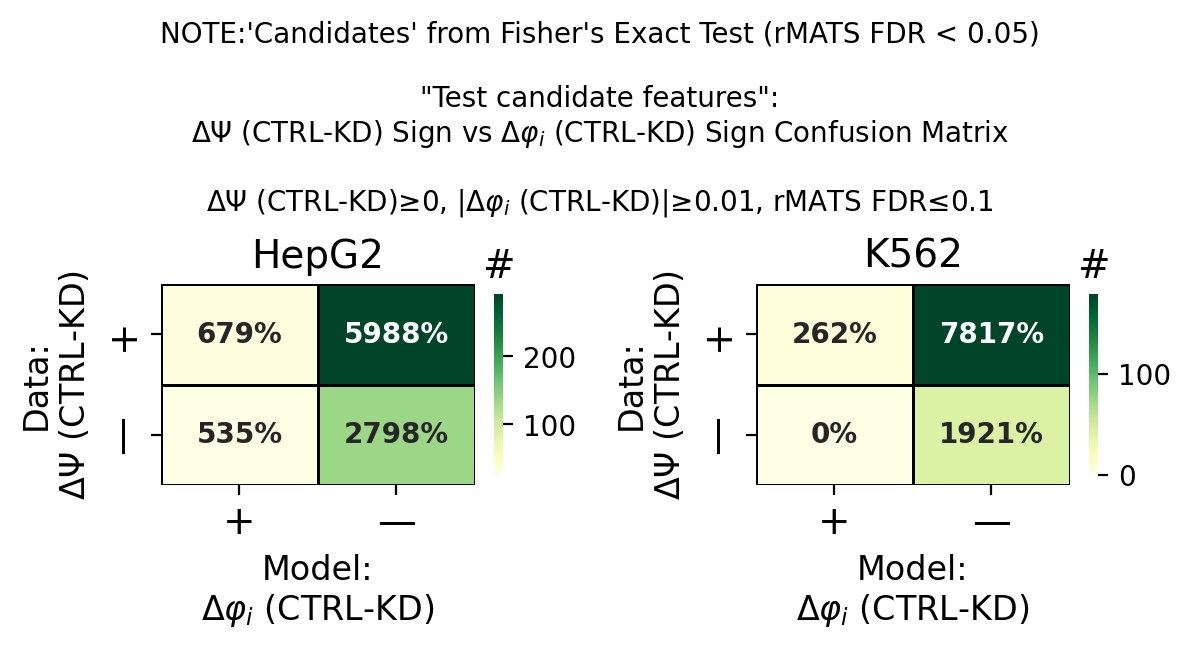

2025-10-08 15:14:30.978 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,7.142857,58.571429
—,6.190476,28.095238


2025-10-08 15:14:31.064 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,2.020202,81.313131
—,0.000000,16.666667


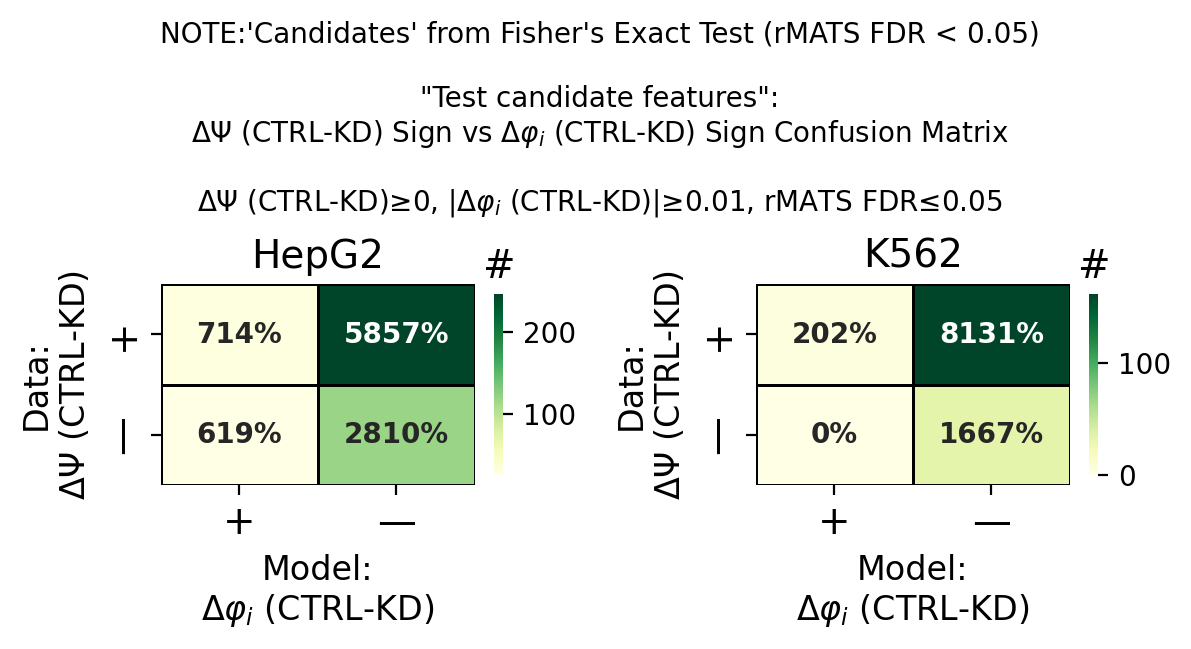

2025-10-08 15:14:31.426 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,0.0,59.243697
—,0.0,40.756303


2025-10-08 15:14:31.512 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,27.777778,24.074074
—,12.962963,35.185185


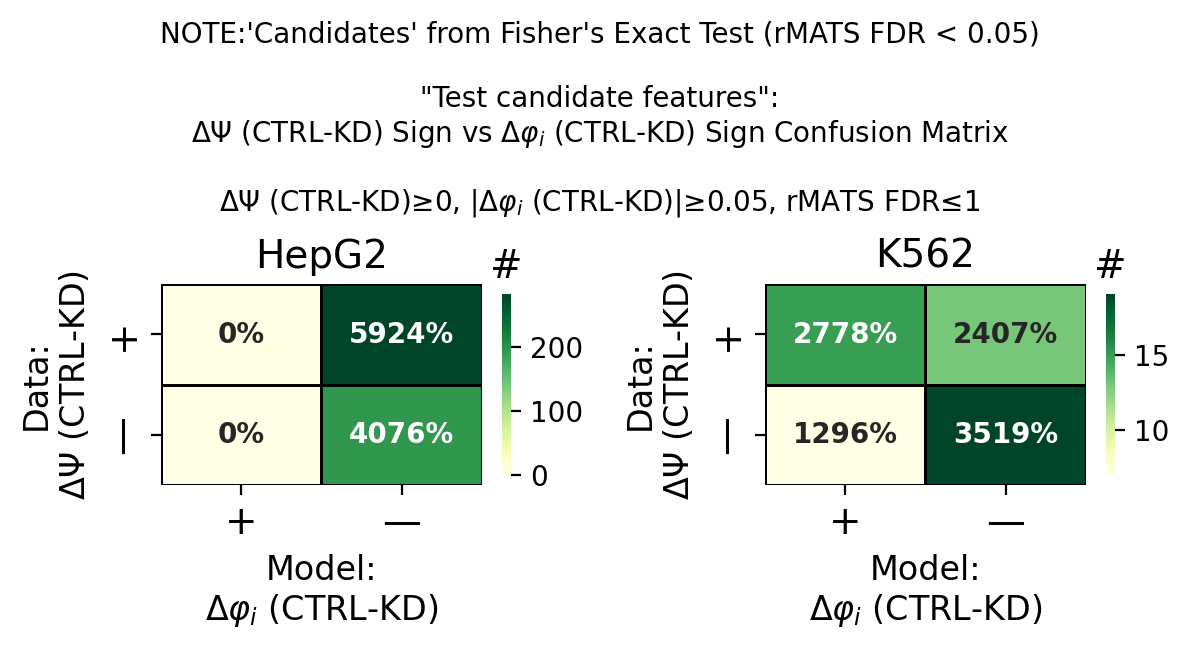

2025-10-08 15:14:31.880 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,0.0,58.241758
—,0.0,41.758242


2025-10-08 15:14:31.971 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,15.384615,23.076923
—,0.000000,61.538462


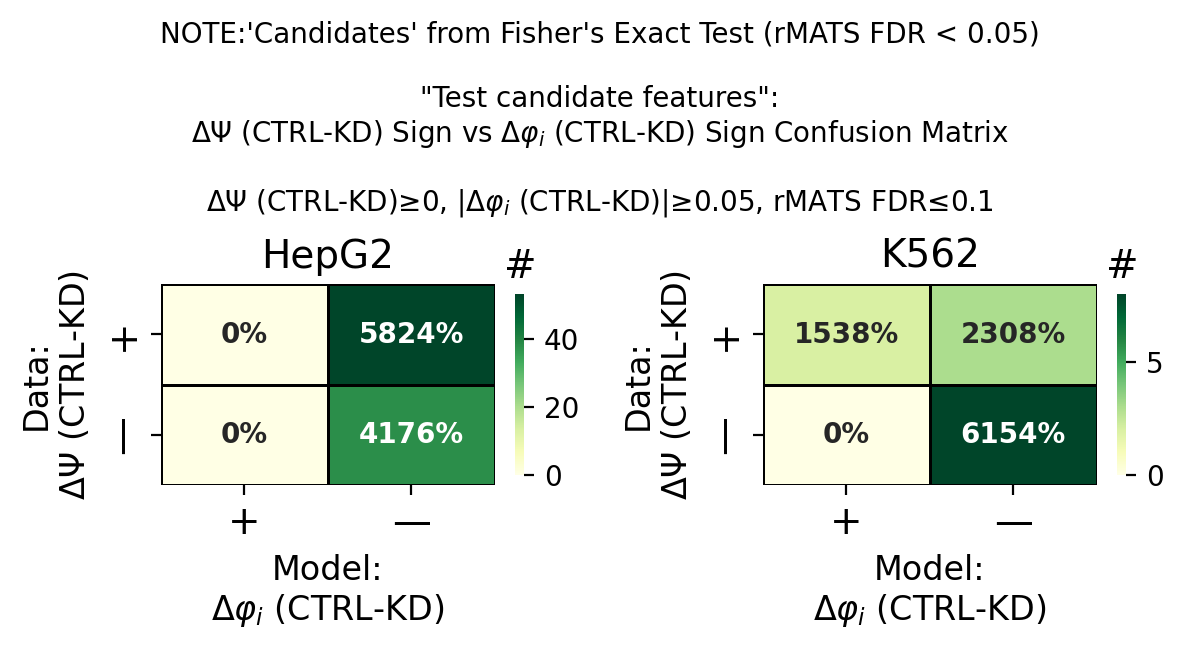

2025-10-08 15:14:32.333 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,0.0,56.962025
—,0.0,43.037975


2025-10-08 15:14:32.420 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,9.090909,27.272727
—,0.000000,63.636364


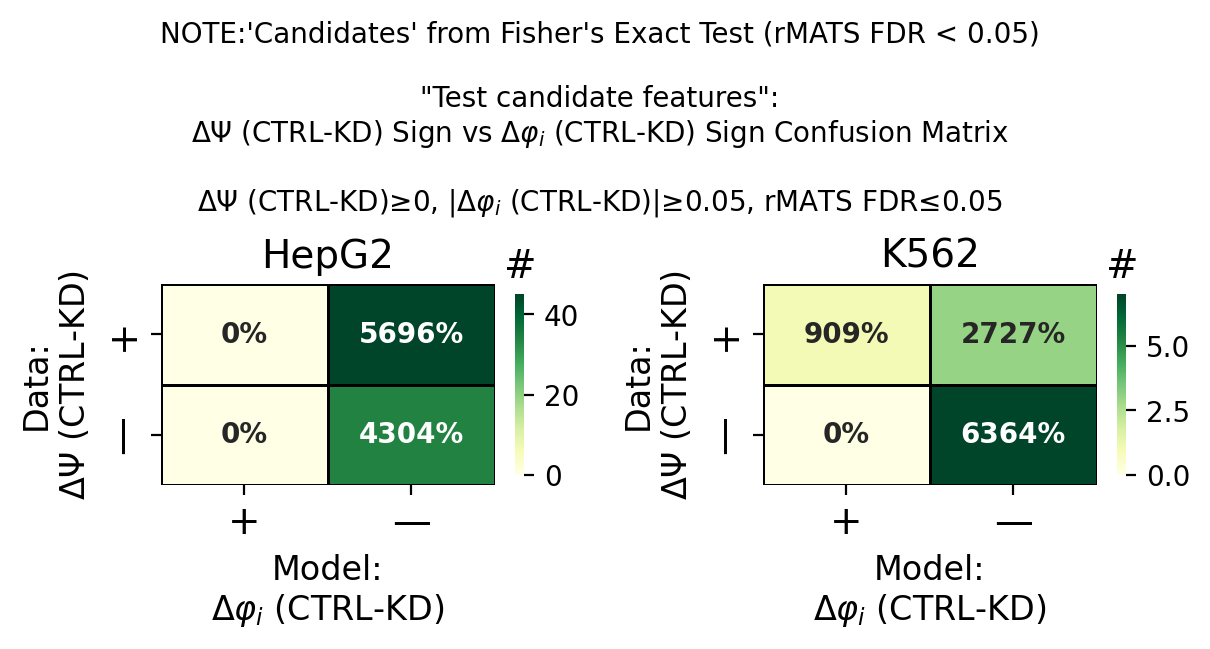

2025-10-08 15:14:32.794 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,11.425061,53.685504
—,6.265356,28.624079


2025-10-08 15:14:32.884 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,2.141328,76.873662
—,0.214133,20.770878


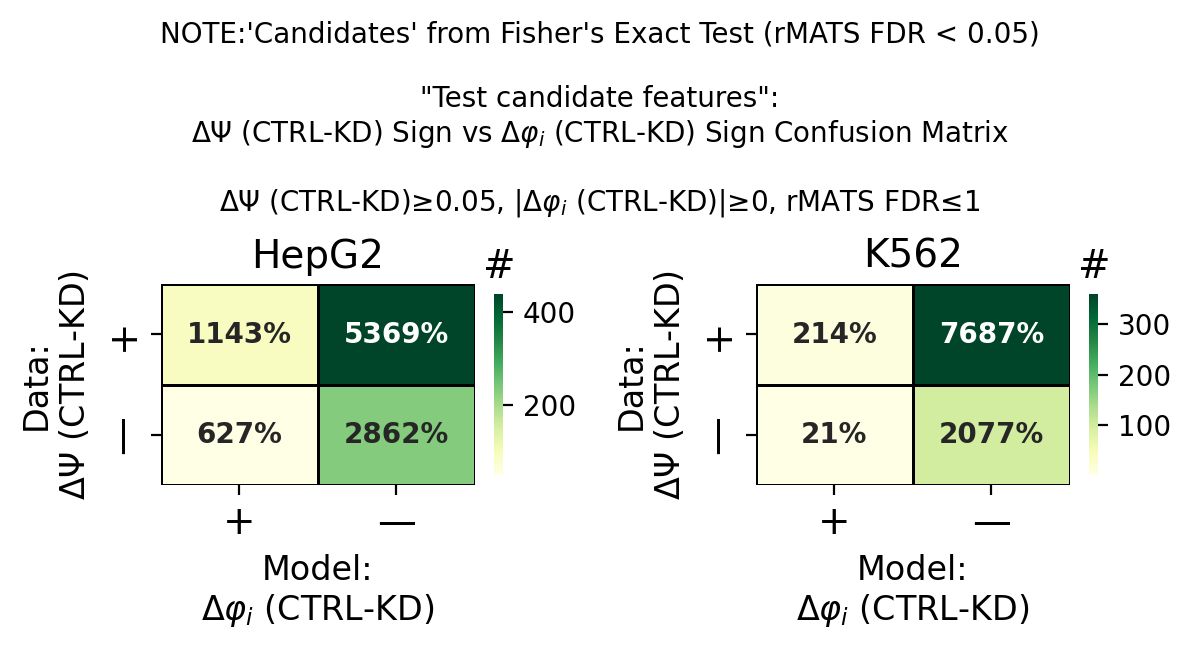

2025-10-08 15:14:33.251 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,12.955466,54.251012
—,6.275304,26.518219


2025-10-08 15:14:33.503 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,2.711864,80.677966
—,0.338983,16.271186


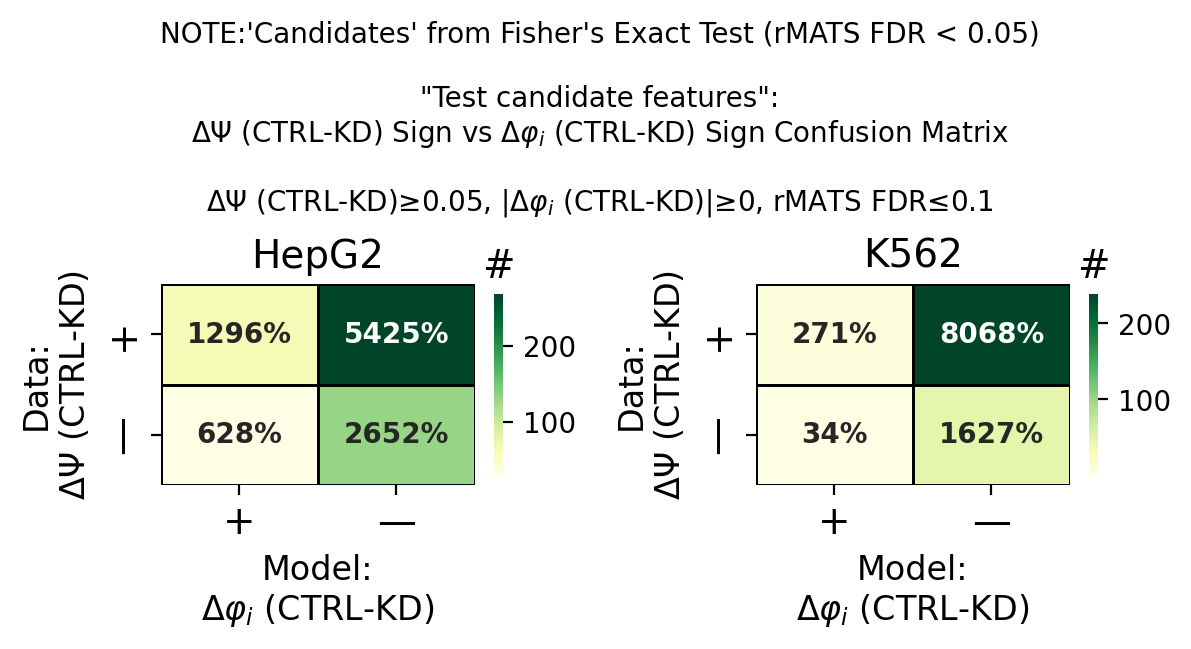

2025-10-08 15:14:33.863 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,13.995485,53.724605
—,6.094808,26.185102


2025-10-08 15:14:33.946 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,1.937984,84.496124
—,0.000000,13.565891


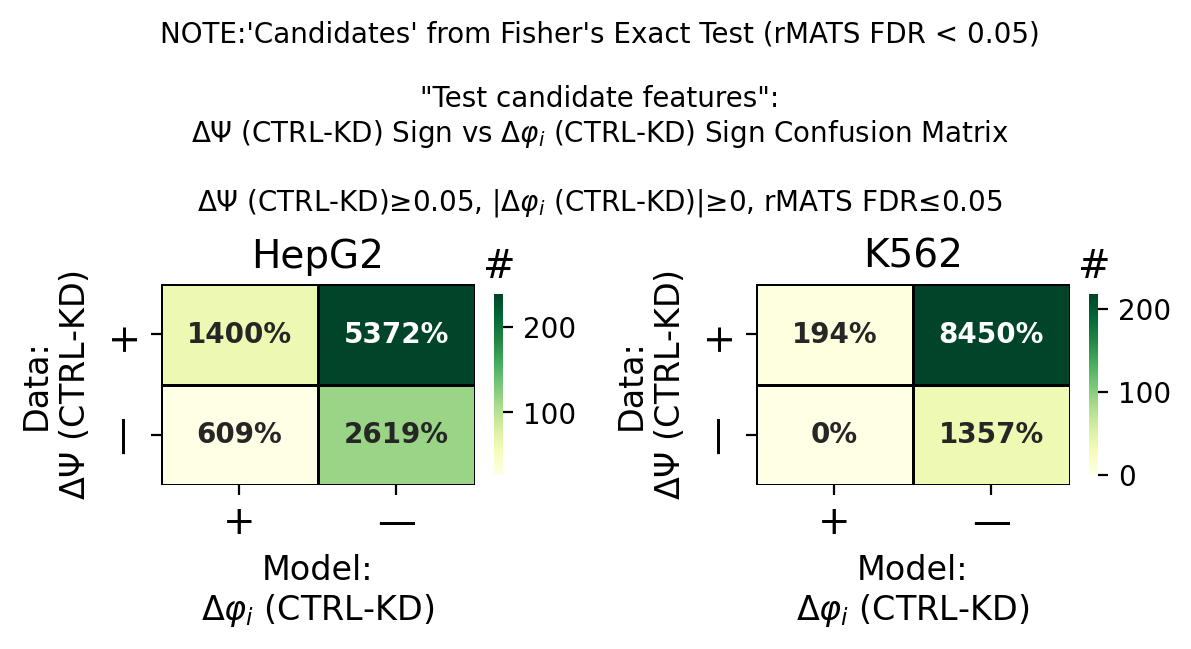

2025-10-08 15:14:34.322 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,7.270030,58.902077
—,3.412463,30.415430


2025-10-08 15:14:34.410 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,2.318841,76.231884
—,0.000000,21.449275


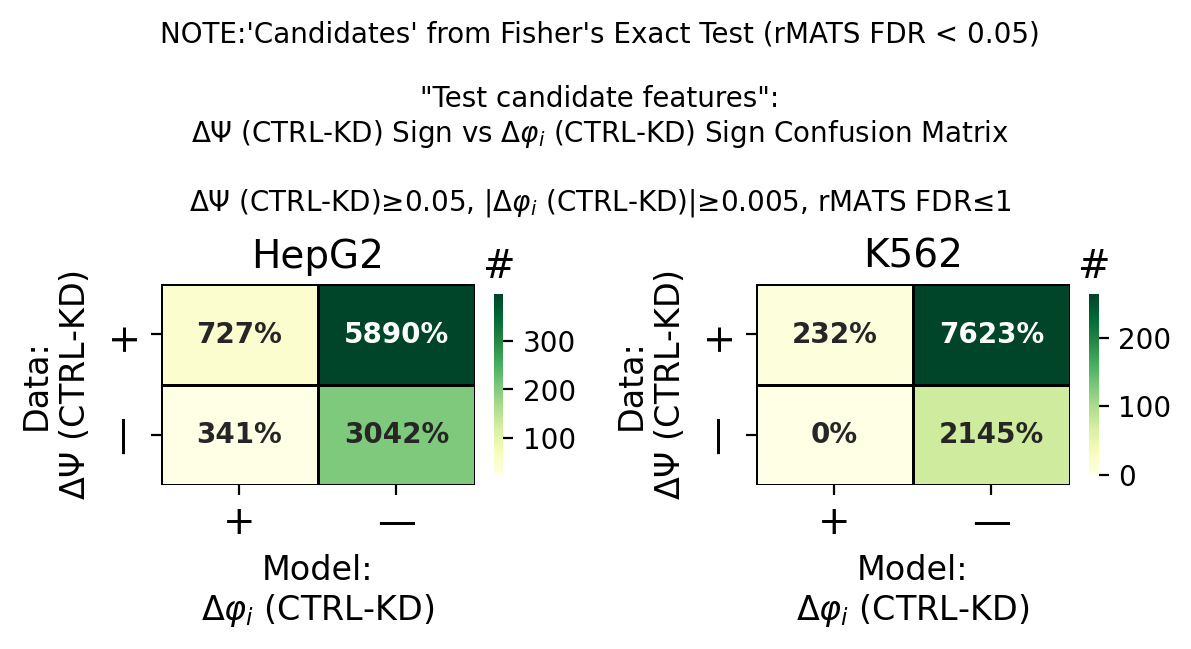

2025-10-08 15:14:34.780 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,9.002433,58.150852
—,4.866180,27.980535


2025-10-08 15:14:34.869 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,2.702703,79.729730
—,0.000000,17.567568


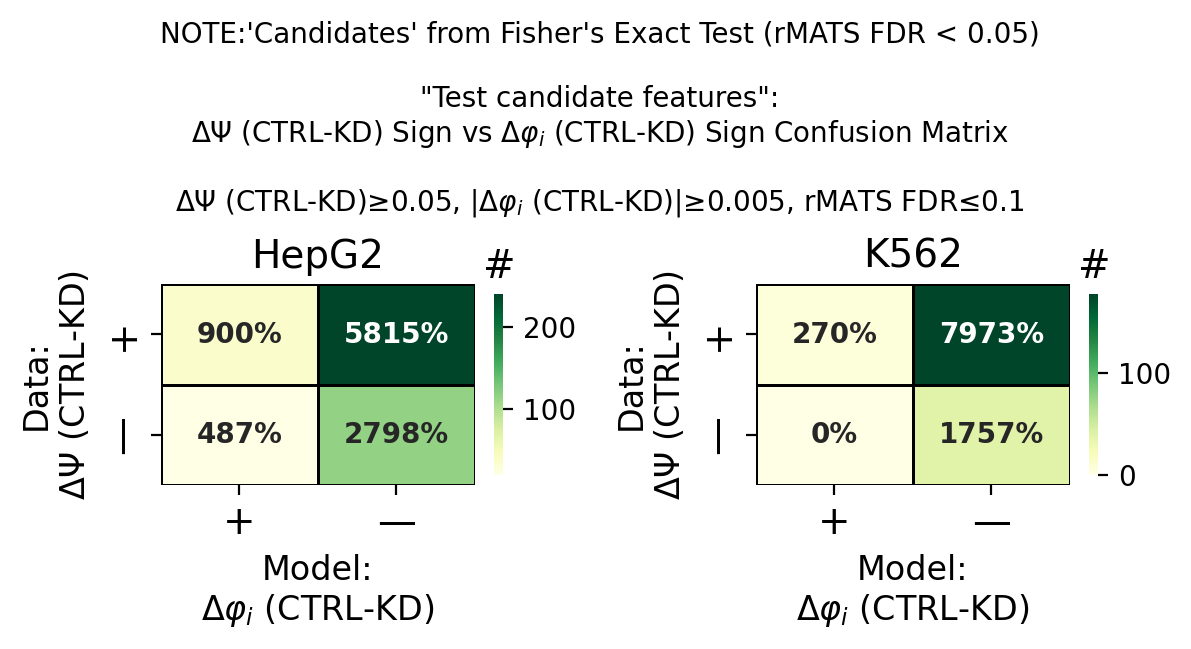

2025-10-08 15:14:35.238 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,9.973046,57.681941
—,5.121294,27.223720


2025-10-08 15:14:35.330 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,1.546392,84.020619
—,0.000000,14.432990


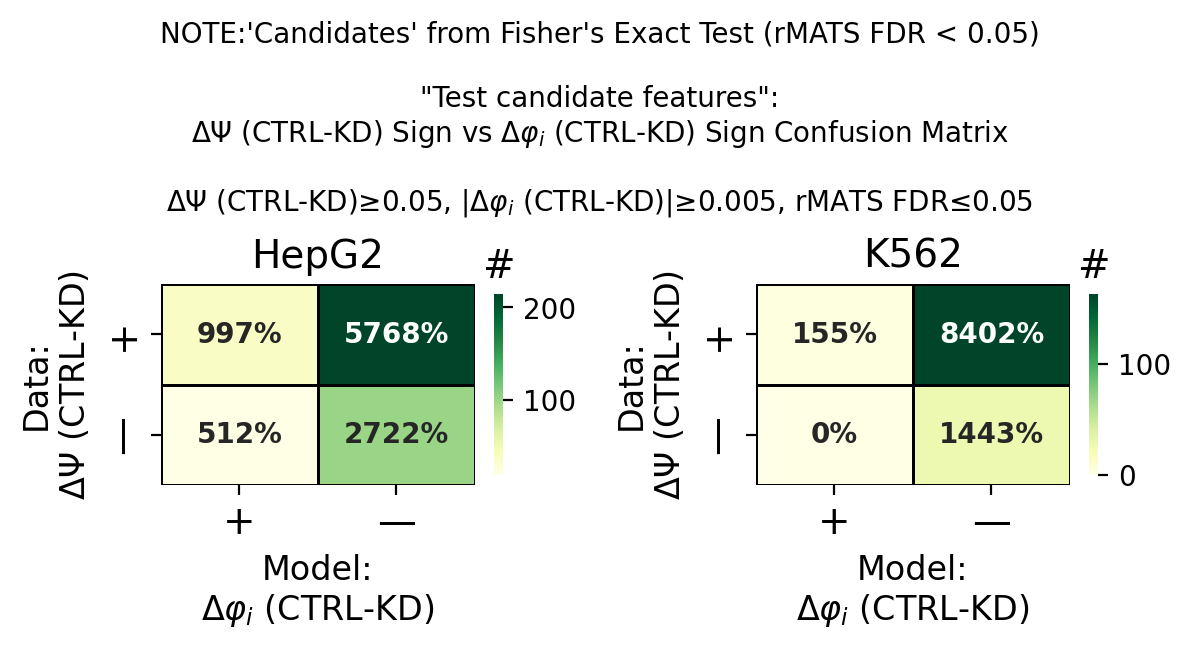

2025-10-08 15:14:35.698 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,6.576728,58.347386
—,3.709949,31.365936


2025-10-08 15:14:35.790 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,2.61194,74.253731
—,0.00000,23.134328


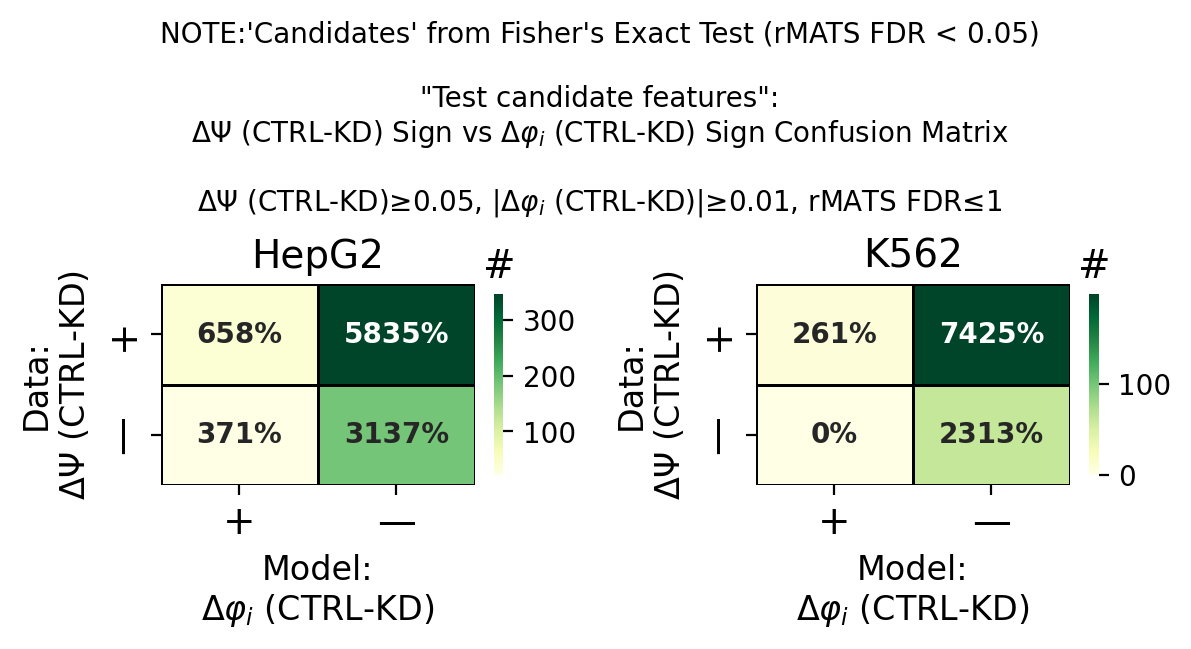

2025-10-08 15:14:36.166 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,7.945205,57.808219
—,5.205479,29.041096


2025-10-08 15:14:36.258 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,2.97619,78.571429
—,0.00000,18.452381


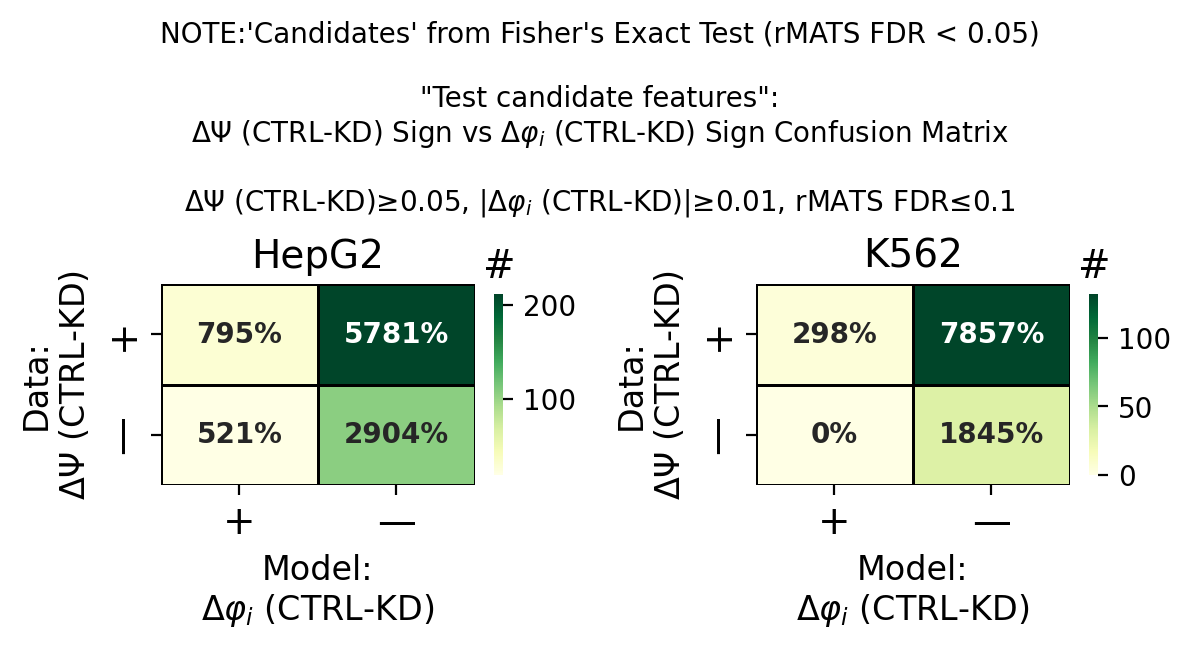

2025-10-08 15:14:36.797 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,8.761329,57.099698
—,5.740181,28.398792


2025-10-08 15:14:36.889 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,2.040816,82.993197
—,0.000000,14.965986


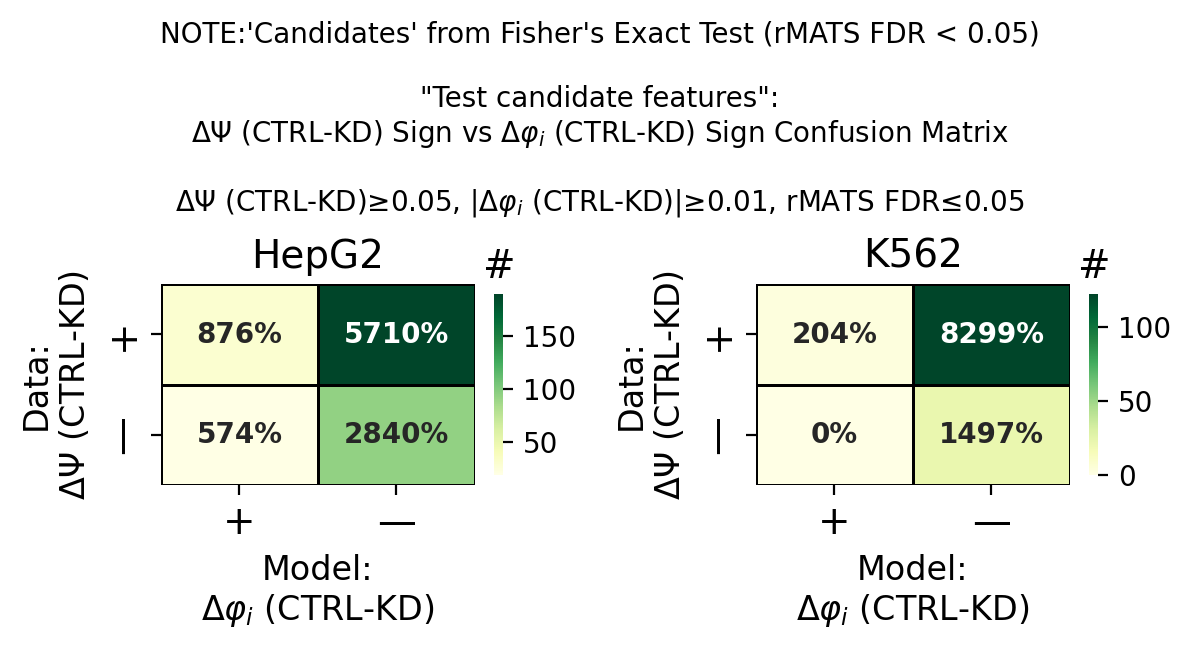

2025-10-08 15:14:37.260 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,0.0,55.238095
—,0.0,44.761905


2025-10-08 15:14:37.350 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,21.428571,28.571429
—,0.000000,50.000000


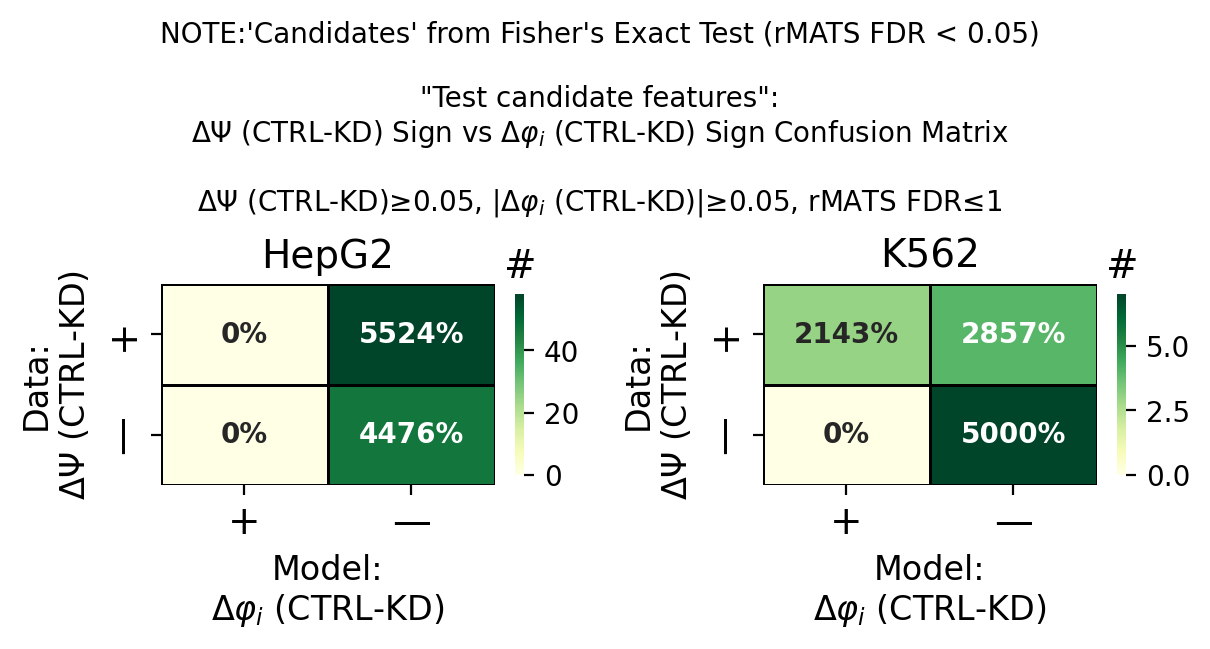

2025-10-08 15:14:37.726 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,0.0,55.223881
—,0.0,44.776119


2025-10-08 15:14:37.816 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,16.666667,25.000000
—,0.000000,58.333333


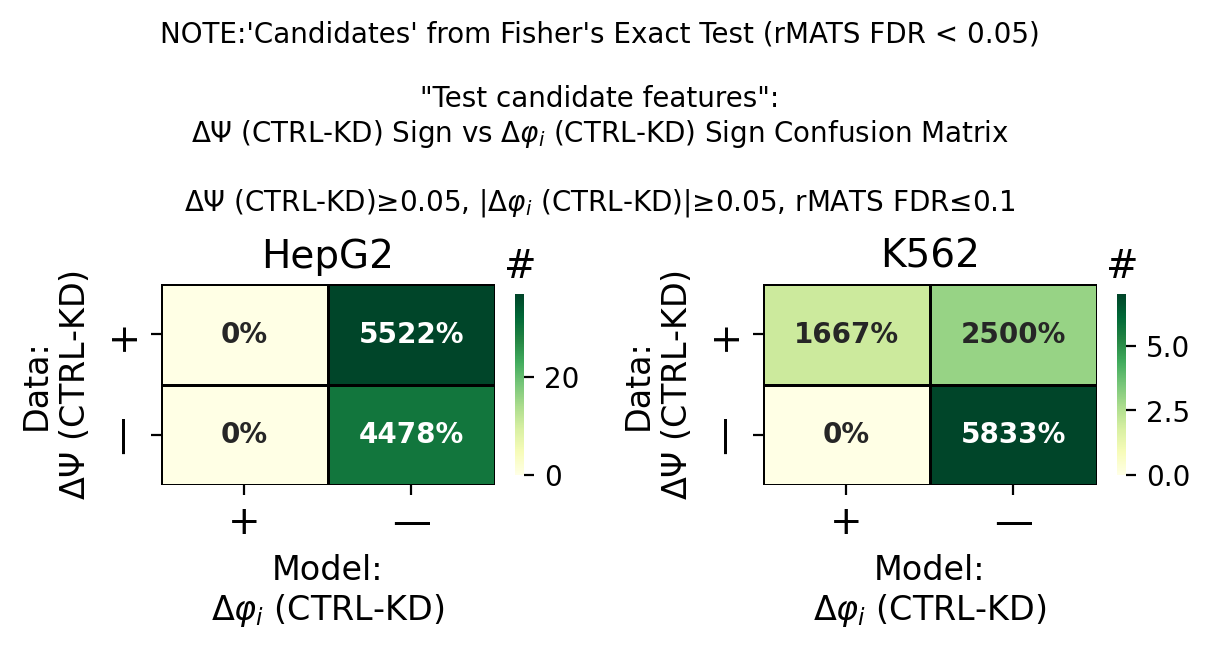

2025-10-08 15:14:38.189 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,0.0,54.83871
—,0.0,45.16129


2025-10-08 15:14:38.278 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.05, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,10.0,30.0
—,0.0,60.0


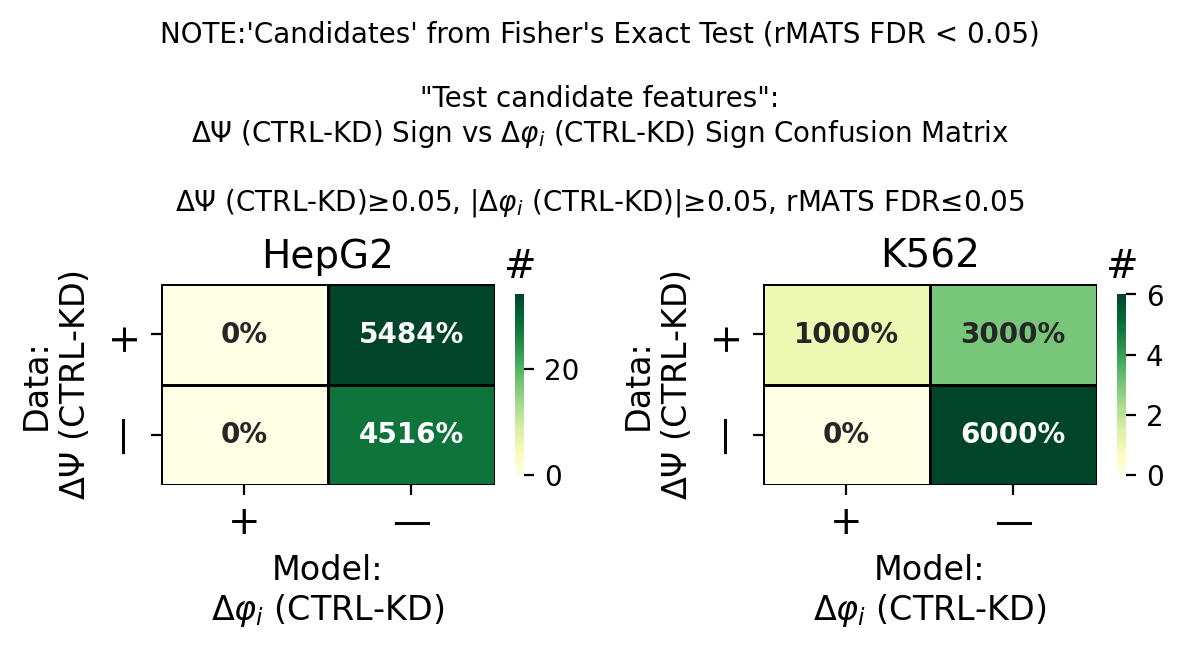

2025-10-08 15:14:38.651 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,12.401055,50.395778
—,7.124011,30.079156


2025-10-08 15:14:38.739 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤1


,+,—
dPSI Sign,,
+,1.818182,78.636364
—,0.000000,19.545455


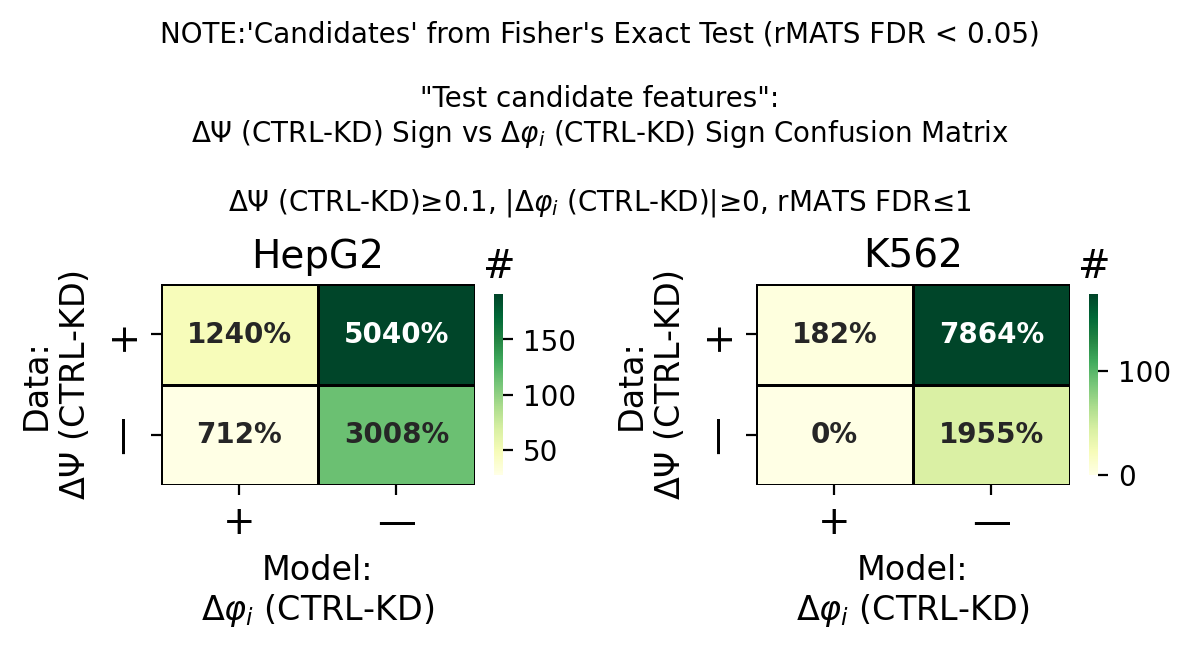

2025-10-08 15:14:39.110 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,13.230769,48.923077
—,7.692308,30.153846


2025-10-08 15:14:39.205 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.1


,+,—
dPSI Sign,,
+,1.621622,80.540541
—,0.000000,17.837838


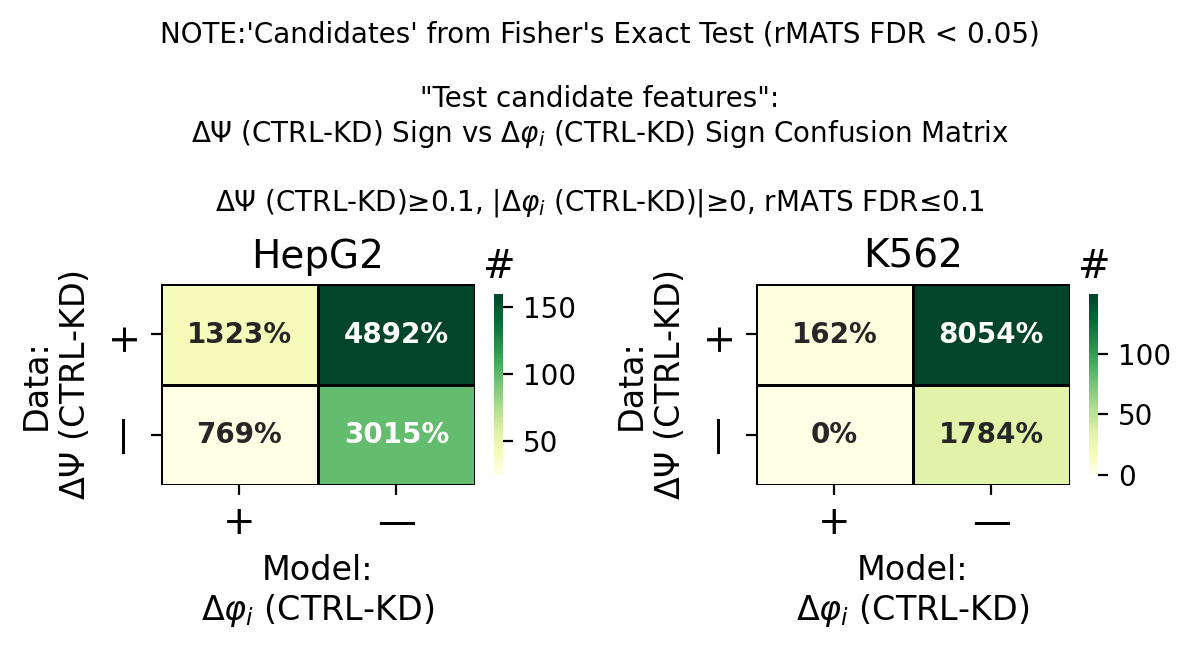

2025-10-08 15:14:39.578 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,13.770492,48.524590
—,7.213115,30.491803


2025-10-08 15:14:39.667 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0, FDR≤0.05


,+,—
dPSI Sign,,
+,1.183432,82.248521
—,0.000000,16.568047


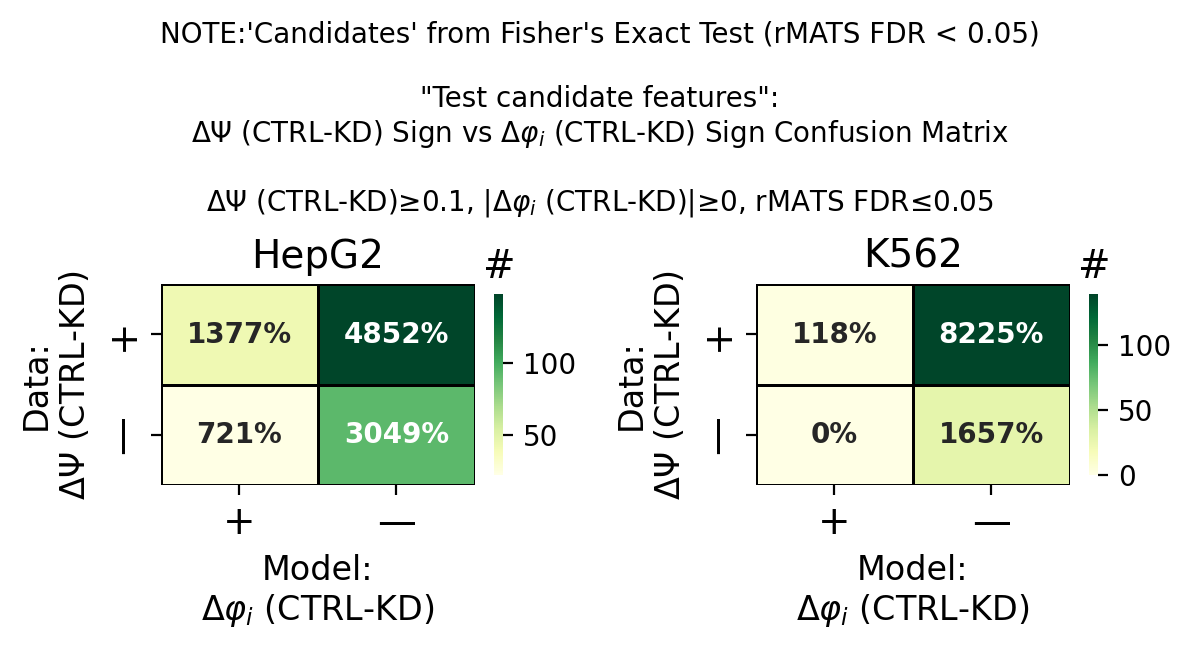

2025-10-08 15:14:40.217 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,7.301587,55.238095
—,5.079365,32.380952


2025-10-08 15:14:40.307 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤1


,+,—
dPSI Sign,,
+,1.764706,78.235294
—,0.000000,20.000000


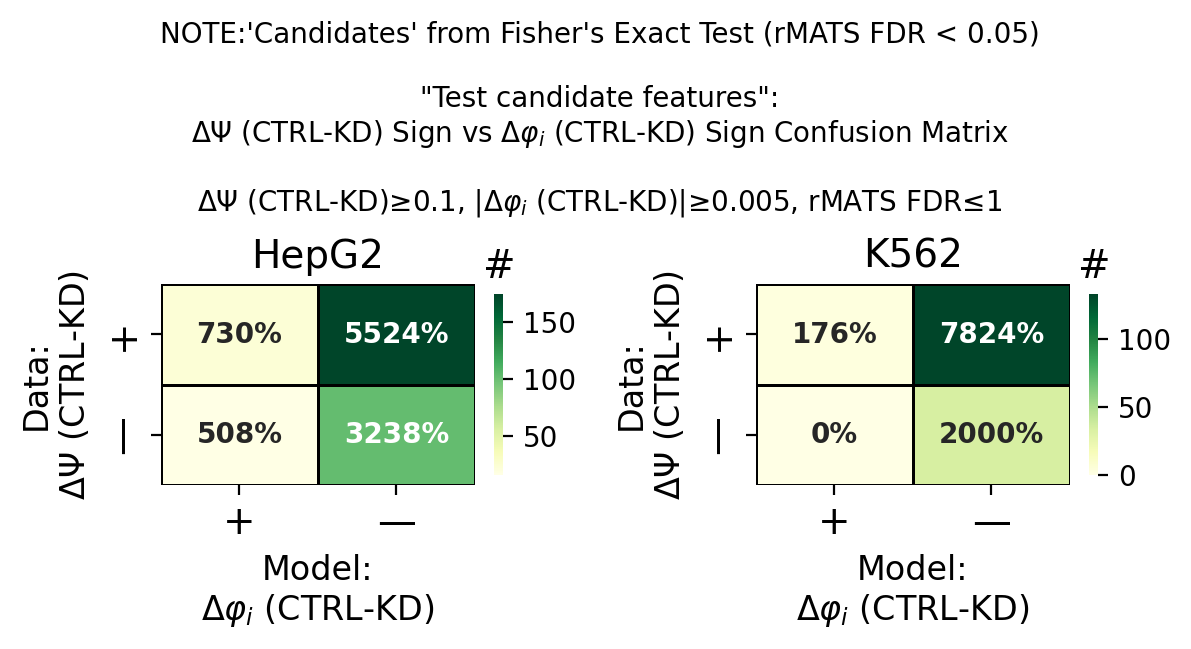

2025-10-08 15:14:40.683 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,7.518797,53.759398
—,5.639098,33.082707


2025-10-08 15:14:40.773 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.1


,+,—
dPSI Sign,,
+,1.360544,80.272109
—,0.000000,18.367347


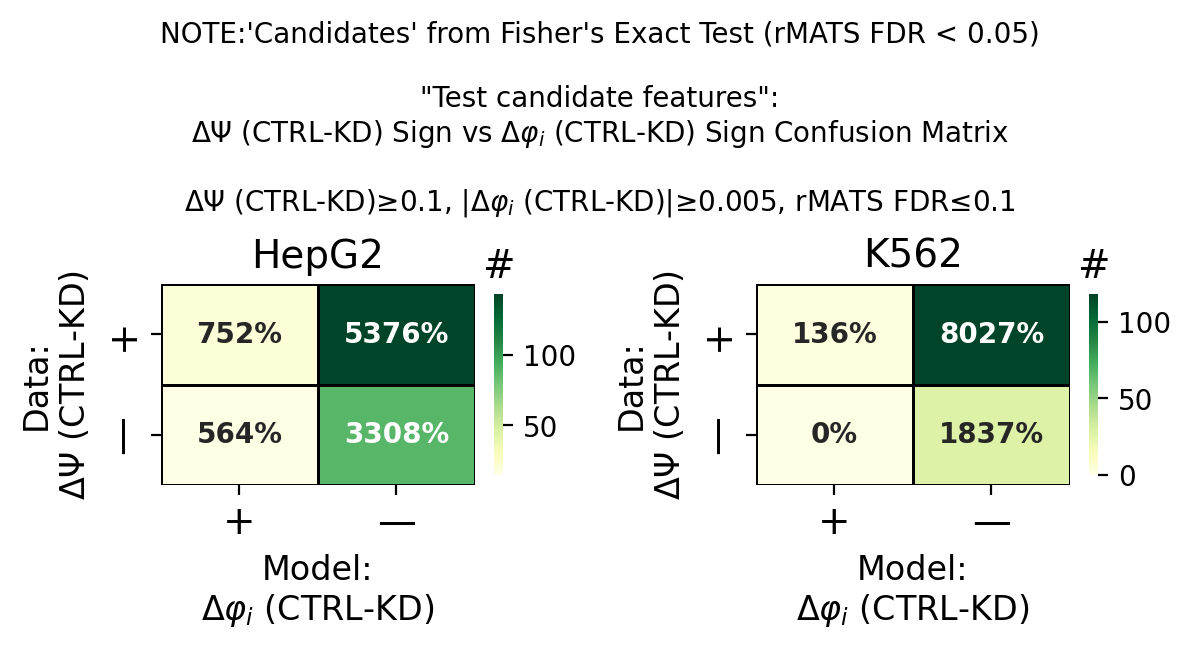

2025-10-08 15:14:41.143 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,7.905138,52.964427
—,5.928854,33.201581


2025-10-08 15:14:41.229 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.005, FDR≤0.05


,+,—
dPSI Sign,,
+,0.740741,82.222222
—,0.000000,17.037037


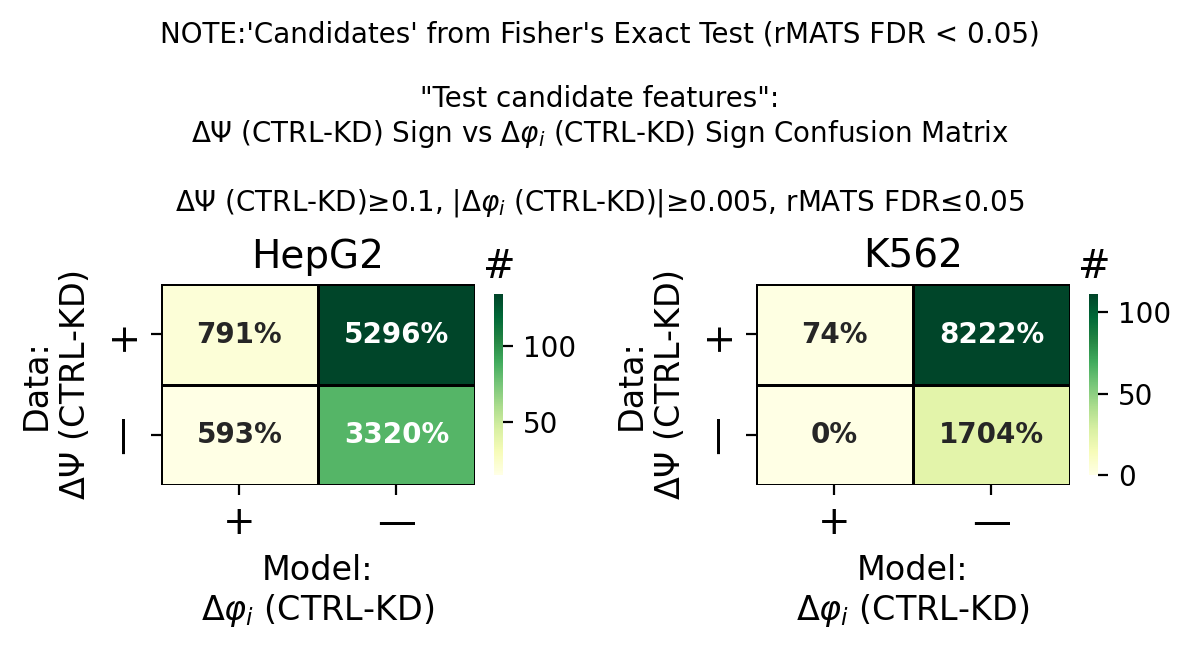

2025-10-08 15:14:41.601 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,6.666667,54.035088
—,5.614035,33.684211


2025-10-08 15:14:41.698 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤1


,+,—
dPSI Sign,,
+,1.503759,76.691729
—,0.000000,21.804511


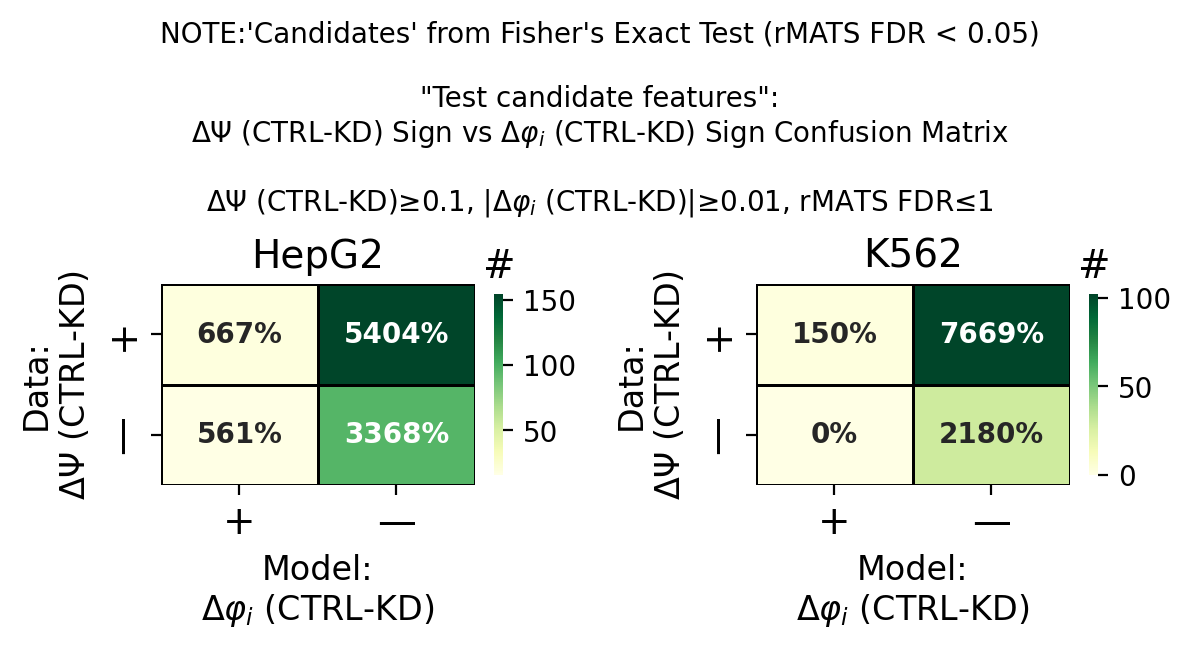

2025-10-08 15:14:42.071 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,6.611570,53.305785
—,6.198347,33.884298


2025-10-08 15:14:42.156 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.1


,+,—
dPSI Sign,,
+,0.884956,78.761062
—,0.000000,20.353982


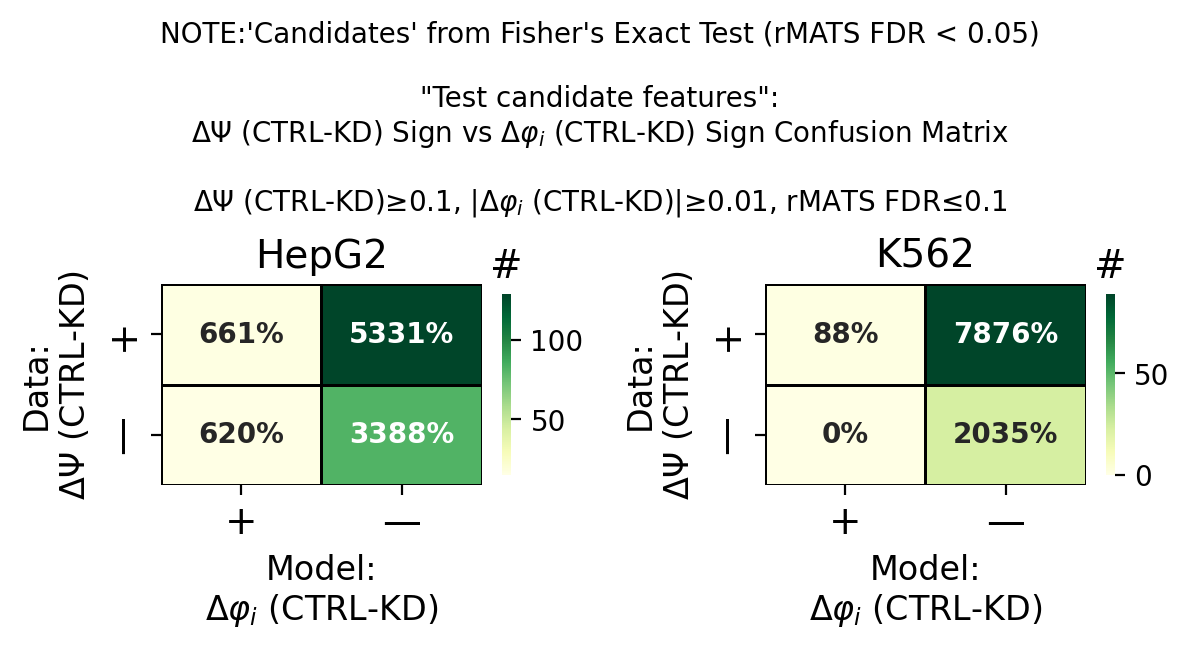

2025-10-08 15:14:42.519 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,6.956522,52.173913
—,6.521739,34.347826


2025-10-08 15:14:42.603 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.01, FDR≤0.05


,+,—
dPSI Sign,,
+,0.961538,80.769231
—,0.000000,18.269231


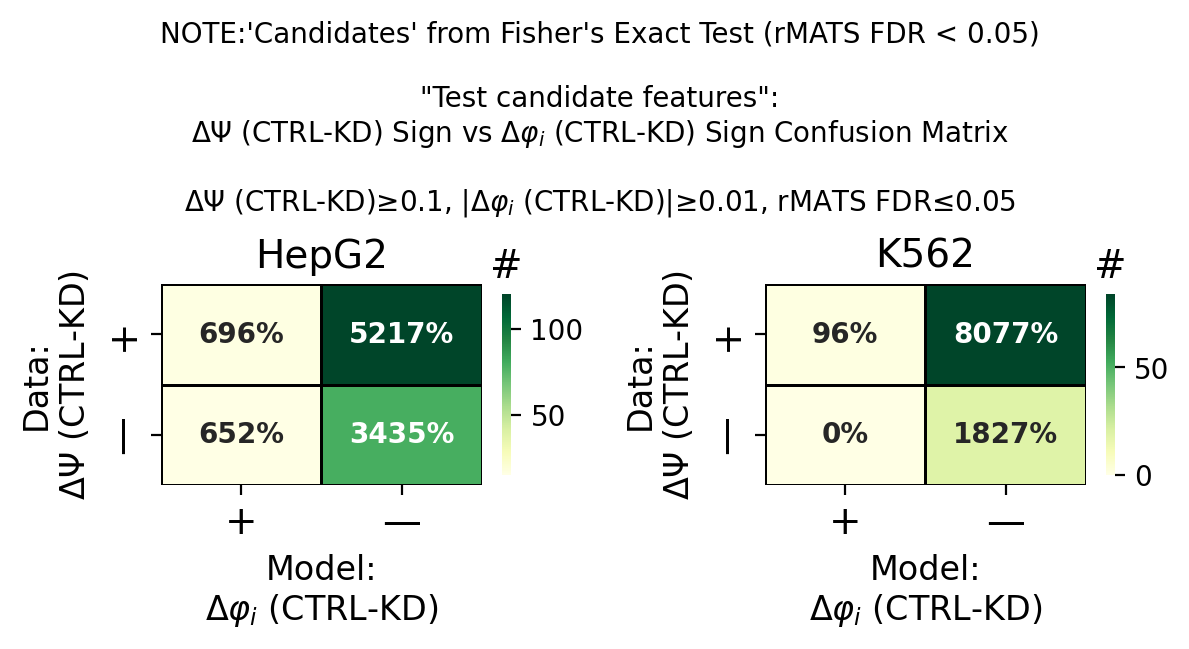

2025-10-08 15:14:42.972 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,0.0,53.448276
—,0.0,46.551724


2025-10-08 15:14:43.062 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤1


,+,—
dPSI Sign,,
+,20.0,10.0
—,0.0,70.0


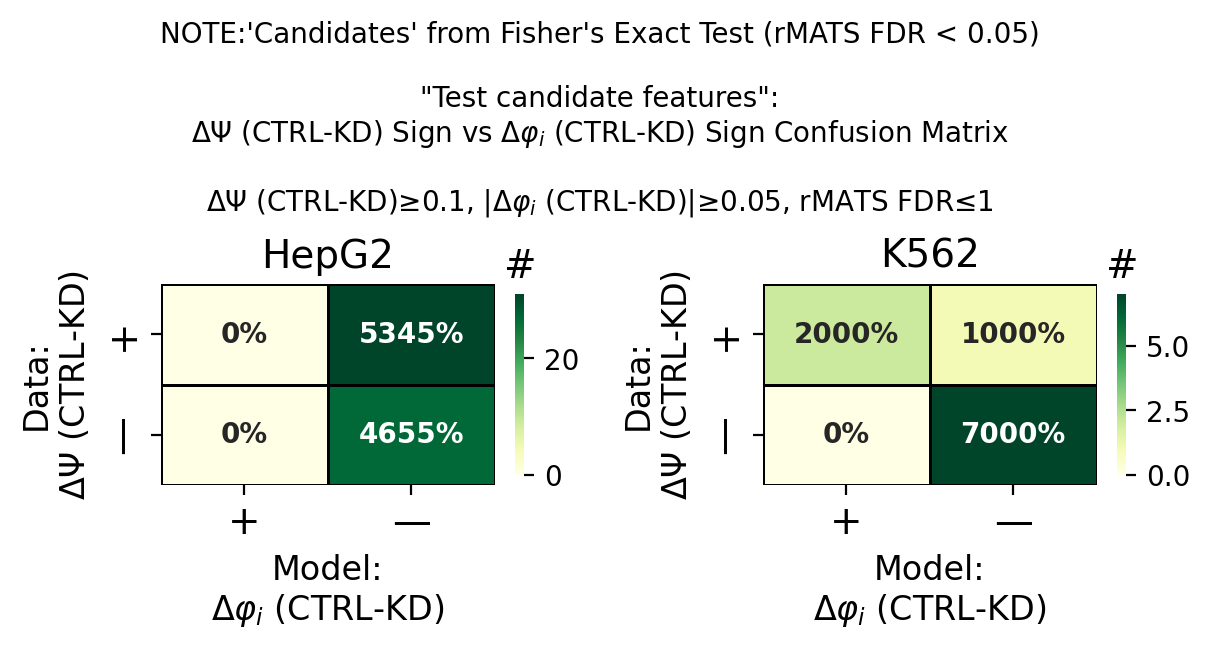

2025-10-08 15:14:43.429 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,0.0,52.941176
—,0.0,47.058824


2025-10-08 15:14:43.708 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.1


,+,—
dPSI Sign,,
+,11.111111,11.111111
—,0.000000,77.777778


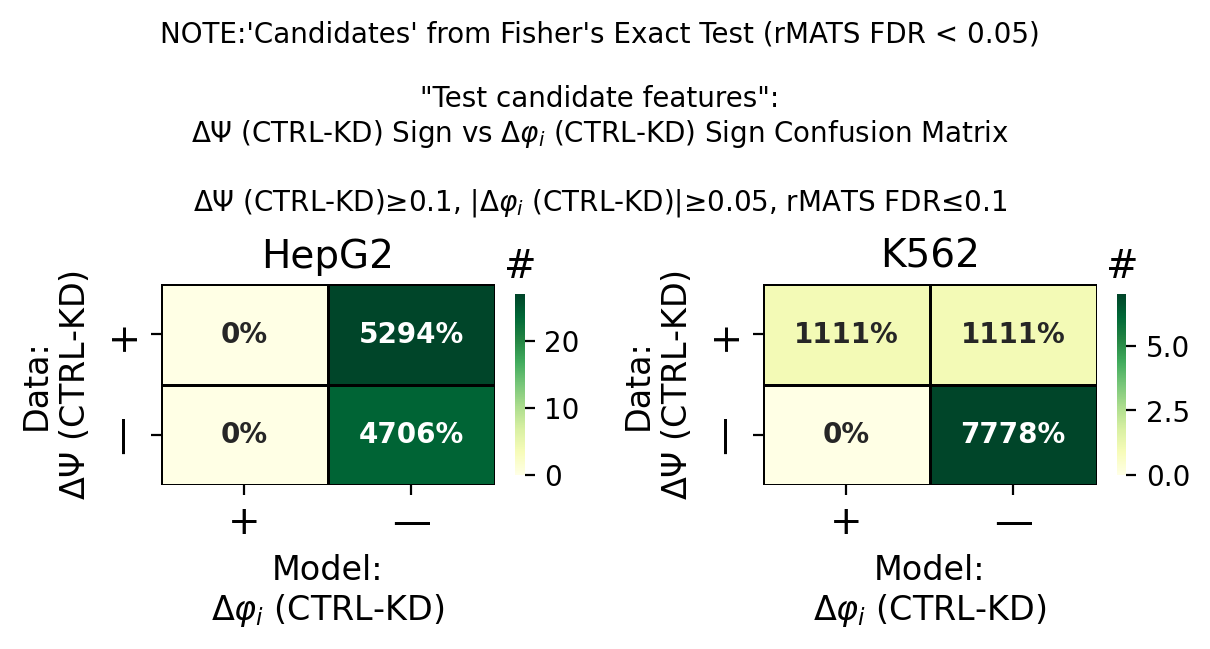

2025-10-08 15:14:44.079 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: HepG2, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,0.0,53.061224
—,0.0,46.938776


2025-10-08 15:14:44.165 | INFO     | 1_shap_network_analyzer:create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign:8883 - Data Mode: test candidate features, Cell Line: K562, dPSI≥0.1, |ΔSHAP|≥0.05, FDR≤0.05


,+,—
dPSI Sign,,
+,12.5,12.5
—,0.0,75.0


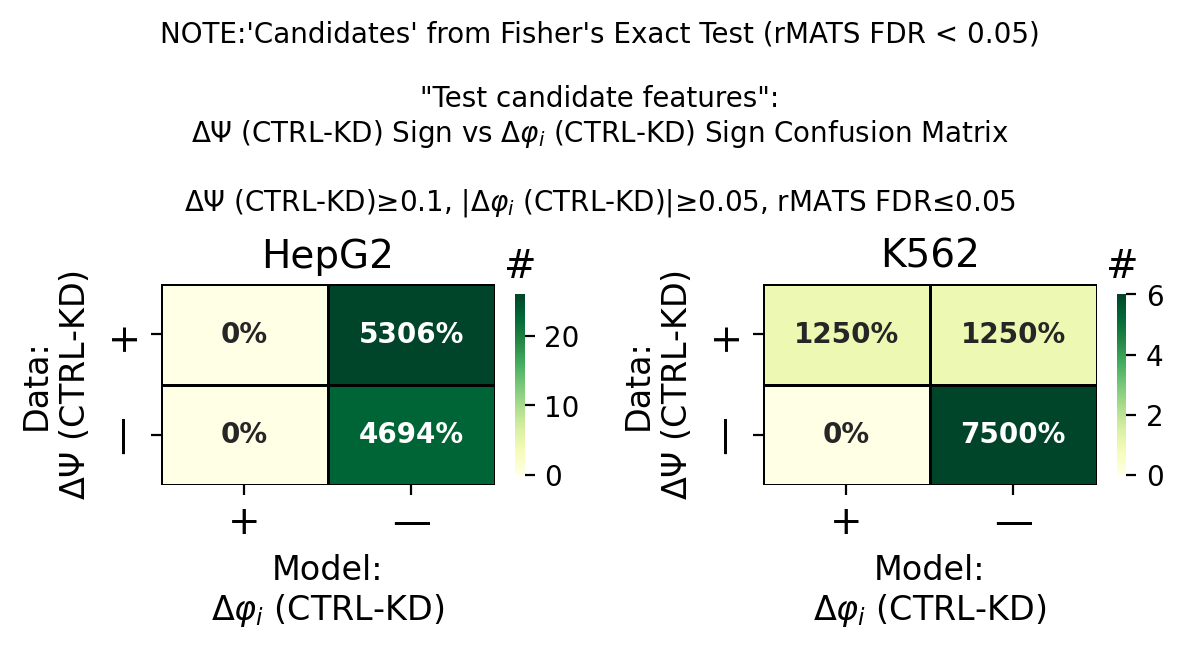

In [3]:
for mode in input_data_modes: 
    investigator.create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign(
        across_thresholds = False, 
        data_mode = mode
    )

In [ ]:
for mode in input_data_modes: 
    investigator.create_confusion_matrices_for_dpsi_sign_vs_local_SHAP_sign(
        across_thresholds = True,
        data_mode = mode
    )